# Group 6 - Painting Classification

On this notebook, we start by getting the dataset generated in the first notebook (EDA) and then apply pre trained models.

To track the evolution of the different model results we used Weights and Biases (W&B).

## 0. Setup

In [1]:
# Install dependencies 
!pip install wandb -q

In [2]:
# Import all libraries we'll need
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from keras import Model, Input
from keras.layers import GlobalAveragePooling2D, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
from collections import Counter

# Import Models
from keras.applications.vgg16 import VGG16
from keras.applications import EfficientNetB0
from keras.applications import EfficientNetB3
from keras.applications import ResNet50


# Resnet Preprocess
from keras.applications.resnet import preprocess_input as resnet_preprocess

# W&B imports
import wandb
from wandb.integration.keras import WandbMetricsLogger

# Global settings
IMG_SIZE = 224 #resnet precisa de 224, B0 precisa de 224,VGG16 224, B3 precisa de 300
BATCH_SIZE = 64
NUM_CLASSES = 23
SEED = 6666
AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

2026-04-23 23:34:58.373774: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776987298.588460      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776987298.655823      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776987299.180530      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776987299.180564      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776987299.180567      55 computation_placer.cc:177] computation placer alr

In [3]:
# Login to W&B
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: adriananetoribeiro (miguelcorreia4-nova-information-management-school) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
# This folder should contain train/, val/, test/ subfolders

split_dir = "/kaggle/input/datasets/drir04/wikiart-split/wikiart_split"

train_dir = os.path.join(split_dir, "train")
val_dir = os.path.join(split_dir, "val")
test_dir = os.path.join(split_dir, "test")

# Quick check that the paths are correct
for d in [train_dir, val_dir, test_dir]:
    n_classes = len(os.listdir(d))
    n_images = sum(len(os.listdir(os.path.join(d, c))) for c in os.listdir(d))
    print(f"{os.path.basename(d):5s}: {n_classes} classes, {n_images} images")

train: 23 classes, 8002 images
val  : 23 classes, 2670 images
test : 23 classes, 2668 images


## 1. Helper Functions

These functions will be reused across all models to evaluate performance and visualize results.

In [5]:
def evaluate_model(model, dataset, class_names, dataset_name="Validation"):
    """
    Run the model on a dataset and compute metrics.
    Returns true labels, predicted labels, weighted F1, and macro F1.
    """
    y_true = []
    y_pred = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(predictions, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    f1_macro = f1_score(y_true, y_pred, average='macro')

    print(f"\n{dataset_name} Results:")
    print(f"  Weighted F1: {f1_weighted:.4f}")
    print(f"  Macro F1:    {f1_macro:.4f}")
    print(f"\nPer-class report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    return y_true, y_pred, f1_weighted, f1_macro


def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    """
    Plot a normalized confusion matrix.
    Each cell shows the proportion of true class X that was predicted as class Y.
    The diagonal shows correct predictions — off-diagonal shows confusions.
    """
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=55, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()
    return fig


def plot_training_history(history, title="Training History"):
    """
    Plot training curves: loss, accuracy, and F1 scores over epochs.
    A large gap between train and val curves indicates overfitting.
    """
    has_f1 = 'val_f1_weighted' in history.history

    n_plots = 3 if has_f1 else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))

    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].legend()

    if has_f1:
        axes[2].plot(history.history['val_f1_weighted'], label='Weighted F1')
        axes[2].plot(history.history['val_f1_macro'], label='Macro F1')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('F1 Score')
        axes[2].set_title(f'{title} — F1 Scores')
        axes[2].legend()

    plt.tight_layout()
    plt.show()
    return fig


class F1Callback(callbacks.Callback):
    """
    Calculates weighted and macro F1 on the validation set at the end of each epoch.
    Results are added to the Keras logs dict, which WandbMetricsLogger picks up automatically.
    """
    def __init__(self, val_dataset):
        super().__init__()
        self.val_dataset = val_dataset

    def on_epoch_end(self, epoch, logs=None):
        y_true = []
        y_pred = []

        for images, labels in self.val_dataset:
            predictions = self.model.predict(images, verbose=0)
            y_true.extend(labels.numpy())
            y_pred.extend(np.argmax(predictions, axis=1))

        f1_w = f1_score(y_true, y_pred, average='weighted')
        f1_m = f1_score(y_true, y_pred, average='macro')

        # Add to Keras logs — WandbMetricsLogger will pick these up automatically
        logs['val_f1_weighted'] = f1_w
        logs['val_f1_macro'] = f1_m

        print(f" — val_f1_weighted: {f1_w:.4f} — val_f1_macro: {f1_m:.4f}")

## 2. Pre-trained Models

In this section we ran 3 different pre-trained models:
 - VGG16
 - ResNet50
 - EfficientNet B3

### 2.1 VGG16

For this model we used Optuna to find the best parameters, but the results were not better than the other models so we commented the code to decrease run time and instead copied the obtained results into a dictionary.

#### 2.1.1 Load data and define class_weights

In [6]:
# Load images from the split folders
IMG_SIZE = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int',
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int',
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int',
)

# class_names is the list of painter names, in the order Keras assigned them
class_names = train_ds.class_names
print(f"\nClasses ({len(class_names)}):")
for i, name in enumerate(class_names):
    print(f"  {i:2d}: {name}")

Found 8002 files belonging to 23 classes.


I0000 00:00:1776987357.685223      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776987357.691299      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 2670 files belonging to 23 classes.
Found 2668 files belonging to 23 classes.

Classes (23):
   0: Albrecht_Durer
   1: Boris_Kustodiev
   2: Camille_Pissarro
   3: Childe_Hassam
   4: Claude_Monet
   5: Edgar_Degas
   6: Eugene_Boudin
   7: Gustave_Dore
   8: Ilya_Repin
   9: Ivan_Aivazovsky
  10: Ivan_Shishkin
  11: John_Singer_Sargent
  12: Marc_Chagall
  13: Martiros_Saryan
  14: Nicholas_Roerich
  15: Pablo_Picasso
  16: Paul_Cezanne
  17: Pierre_Auguste_Renoir
  18: Pyotr_Konchalovsky
  19: Raphael_Kirchner
  20: Rembrandt
  21: Salvador_Dali
  22: Vincent_van_Gogh


In [7]:
# Count how many images each painter has in the training set
train_labels = []
for _, labels in train_ds:
    train_labels.extend(labels.numpy())
train_labels = np.array(train_labels)

label_counts = Counter(train_labels)
total_samples = len(train_labels)

# Compute weights: rarer classes get higher weights
# Formula: total_samples / (num_classes * count_for_this_class)
class_weights = {
    cls: total_samples / (NUM_CLASSES * count)
    for cls, count in label_counts.items()
}

print(f"{'Painter':30s}  {'Samples':>8s}  {'Weight':>8s}")
print("-" * 50)
for cls_idx in sorted(class_weights.keys()):
    print(f"{class_names[cls_idx]:30s}  {label_counts[cls_idx]:8d}  {class_weights[cls_idx]:8.3f}")

Painter                          Samples    Weight
--------------------------------------------------
Albrecht_Durer                       348     1.000
Boris_Kustodiev                      266     1.308
Camille_Pissarro                     373     0.933
Childe_Hassam                        231     1.506
Claude_Monet                         560     0.621
Edgar_Degas                          257     1.354
Eugene_Boudin                        233     1.493
Gustave_Dore                         317     1.098
Ilya_Repin                           227     1.533
Ivan_Aivazovsky                      242     1.438
Ivan_Shishkin                        218     1.596
John_Singer_Sargent                  329     1.057
Marc_Chagall                         322     1.080
Martiros_Saryan                      242     1.438
Nicholas_Roerich                     764     0.455
Pablo_Picasso                        320     1.087
Paul_Cezanne                         244     1.426
Pierre_Auguste_Renoir          

In [8]:
# Performance optimization
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
def sparse_focal_loss(gamma=2.0, alpha=None):
    if alpha is None:
        alpha_tensor = None
    else:
        alpha_tensor = tf.constant(alpha, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        # Get the probability of the true class
        probs = tf.reduce_max(y_pred * tf.one_hot(y_true, NUM_CLASSES), axis=-1)
        focal_weight = tf.pow(1.0 - probs, gamma)
        if alpha_tensor is not None:
            alpha_weight = tf.gather(alpha_tensor, y_true)
            focal_weight = focal_weight * alpha_weight
        return focal_weight * ce

    return loss_fn

#### 2.1.2 Create model

In [10]:
# !pip install optuna -q
# !pip install optuna optuna-integration[tfkeras] -q

In [11]:
# import optuna
# from optuna.integration import TFKerasPruningCallback
# optuna.logging.set_verbosity(optuna.logging.WARNING)

In [12]:
def build_vgg16_model(dropout=False, dense_units=False, use_aug=False):
    """
    Builds and returns a fresh (uncompiled) VGG16 transfer-learning model.
    Called once per Optuna trial so trials are fully independent.
    """
    base = keras.applications.VGG16(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = inputs

    if use_aug:
        aug = layers.Pipeline([
            layers.RandomContrast(factor=0.2, value_range=(0, 1)),
            layers.RandomSharpness(factor=0.2, value_range=(0, 1)),
            layers.RandomTranslation(height_factor=0.015, width_factor=0.015),
            layers.RandomZoom(height_factor=0.05, width_factor=0.05),
        ])
        x = aug(x)

    x = keras.applications.vgg16.preprocess_input(x)
    x = base(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(dense_units, activation="relu")(x)
    x = keras.layers.Dropout(dropout)(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return keras.Model(inputs, outputs)

In [13]:
# # ROUND 1 — Architecture (dense_units, dropout, augmentation)
# # Base VGG16 frozen — only tune the classification head

# def objective_round1(trial):
#     # Search space
#     dense_units = trial.suggest_categorical('dense_units', [128, 256, 512])
#     dropout     = trial.suggest_float('dropout', 0.2, 0.5)
#     use_aug     = trial.suggest_categorical('use_aug', [True, False])
#     lr          = trial.suggest_float('lr', 1e-5, 1e-3, log=True)

#     trial_model = build_vgg16_model(dropout=dropout, dense_units=dense_units, use_aug=use_aug)
#     trial_model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=lr),
#         loss='sparse_categorical_crossentropy',
#         metrics=['accuracy'])

#     wandb.init(
#         project="wikiart-pre_trained",
#         name=f"VGG-r1-trial-{trial.number}",
#         config=trial.params,
#         reinit=True,)              #required for multi-trial loops

#     history = trial_model.fit(
#         train_ds, validation_data=val_ds,
#         epochs=30,
#         class_weight=class_weights,
#         callbacks=[
#             callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
#             callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
#             F1Callback(val_ds),
#             WandbMetricsLogger(),
#             TFKerasPruningCallback(trial, 'val_accuracy'),],
#         verbose=0,)

#     val_f1 = max(history.history.get('val_f1_weighted', [0]))
#     wandb.log({"val_f1_weighted": val_f1})
#     wandb.finish()
#     return val_f1

# study_r1 = optuna.create_study(
#     direction='maximize',
#     pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
#     sampler=optuna.samplers.TPESampler(seed=SEED),)
# study_r1.optimize(objective_round1, n_trials=20)

# print("\n ROUND 1")
# print(f"  Val F1: {study_r1.best_trial.value:.4f}")
# print(f"  Params: {study_r1.best_trial.params}")

# best_arch = study_r1.best_trial.params

In [14]:
best_arch = {'dense_units': 256, 'dropout': 0.4606937930032976, 'use_aug': False, 'lr': 0.0008389014009114053}

In [15]:
# # ROUND 2 — Training (optimizer, loss, learning_rate_factor, gamma, alpha)
# # The arghitecture used is the one found to be the best in round 1

# def objective_round2(trial):
#     # Search space
#     optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'rmsprop', 'sgd'])
#     loss_name      = trial.suggest_categorical('loss', ['sparse_categorical_crossentropy', 'focal'])
#     lr             = trial.suggest_float('lr', 1e-6, 1e-4, log=True)
#     lr_factor      = trial.suggest_float('lr_factor', 0.2, 0.8)

#     if loss_name == 'focal':
#         gamma     = trial.suggest_float('gamma', 1.0, 5.0)
#         use_alpha = trial.suggest_categorical('use_alpha', [True, False])
#     else:
#         gamma     = None
#         use_alpha = False

#     # Loss
#     if loss_name == 'focal':
#         alpha             = list(class_weights.values()) if use_alpha else None
#         loss_fn           = sparse_focal_loss(gamma=gamma, alpha=alpha)
#         fit_class_weights = None
#     else:
#         loss_fn           = 'sparse_categorical_crossentropy'
#         fit_class_weights = class_weights

#     # Optimizer
#     if optimizer_name == 'adam':
#         opt = keras.optimizers.Adam(learning_rate=lr)
#     elif optimizer_name == 'rmsprop':
#         opt = keras.optimizers.RMSprop(learning_rate=lr)
#     else:
#         opt = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)

#     # Build a fresh model using best architecture from Round 1
#     trial_model = build_vgg16_model(
#         dropout=best_arch['dropout'],
#         dense_units=best_arch['dense_units'],
#         use_aug=best_arch['use_aug'],)
#     trial_model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])

#     wandb.init(
#         project="wikiart-pre_trained",
#         name=f"VGG-r2-trial-{trial.number}",
#         config={**best_arch, **trial.params},
#         reinit=True,)

#     history = trial_model.fit(
#         train_ds, validation_data=val_ds,
#         epochs=30,
#         class_weight=fit_class_weights,
#         callbacks=[
#             callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
#             callbacks.ReduceLROnPlateau(monitor='val_loss', factor=lr_factor, patience=3, min_lr=1e-6),
#             F1Callback(val_ds),
#             WandbMetricsLogger(),
#             TFKerasPruningCallback(trial, 'val_accuracy'),],
#         verbose=0,)

#     val_f1 = max(history.history.get('val_f1_weighted', [0]))
#     wandb.log({"val_f1_weighted": val_f1})
#     wandb.finish()
#     return val_f1

# study_r2 = optuna.create_study(
#     direction='maximize',
#     pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
#     sampler=optuna.samplers.TPESampler(seed=SEED),)
# study_r2.optimize(objective_round2, n_trials=20)

# print("\n ROUND 2")
# print(f"  Val F1: {study_r2.best_trial.value:.4f}")
# print(f"  Params: {study_r2.best_trial.params}")

# best_train = study_r2.best_trial.params

In [16]:
best_train = {'dense_units': 256, 'dropout': 0.4606937930032976, 'use_aug': False, 'lr': 0.0008389014009114053, 'gamma': 2.329106017117682, 'loss': 'focal', 'lr_factor': 0.6138911434233871, 'optimizer': 'rmsprop', 'use_alpha': True}

In [17]:
# Creating the final model

model_vgg = build_vgg16_model(
    dropout=best_arch['dropout'],
    dense_units=best_arch['dense_units'],
    use_aug=best_arch['use_aug'],)

# Optimizer
if best_train['optimizer'] == 'adam':
    opt = keras.optimizers.Adam(best_train['lr'])
elif best_train['optimizer'] == 'rmsprop':
    opt = keras.optimizers.RMSprop(best_train['lr'])
else:
    opt = keras.optimizers.SGD(best_train['lr'], momentum=0.9)

# Loss
if best_train['loss'] == 'focal':
    use_alpha         = best_train.get('use_alpha', False)
    gamma             = best_train.get('gamma', 2.0)
    alpha             = list(class_weights.values()) if use_alpha else None
    loss_fn           = sparse_focal_loss(gamma=gamma, alpha=alpha)
    fit_class_weights = None
else:
    loss_fn           = 'sparse_categorical_crossentropy'
    fit_class_weights = class_weights

model_vgg.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])

wandb.init(
    project="wikiart-pre_trained",
    name="VGG-optuna-final",
    config={**best_arch, **best_train},)

final_history = model_vgg.fit(
    train_ds, validation_data=val_ds,
    epochs=100,
    class_weight=fit_class_weights,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=best_train['lr_factor'], patience=5, min_lr=1e-6),
        F1Callback(val_ds),
        WandbMetricsLogger(),],)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Epoch 1/100


I0000 00:00:1776987387.582386     143 service.cc:152] XLA service 0x785a40008940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776987387.582433     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776987387.582438     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776987388.178408     143 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/126 ━━━━━━━━━━━━━━━━━━━━ 27:16 13s/step - accuracy: 0.0312 - loss: 16.2987

I0000 00:00:1776987399.349556     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.1764 - loss: 6.5045 — val_f1_weighted: 0.3426 — val_f1_macro: 0.3108
126/126 ━━━━━━━━━━━━━━━━━━━━ 63s 402ms/step - accuracy: 0.1769 - loss: 6.4855 - val_accuracy: 0.3805 - val_loss: 1.9608 - learning_rate: 8.3890e-04 - val_f1_weighted: 0.3426 - val_f1_macro: 0.3108
Epoch 2/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.3618 - loss: 2.0758 — val_f1_weighted: 0.4322 — val_f1_macro: 0.4058
126/126 ━━━━━━━━━━━━━━━━━━━━ 28s 226ms/step - accuracy: 0.3621 - loss: 2.0744 - val_accuracy: 0.4596 - val_loss: 1.6625 - learning_rate: 8.3890e-04 - val_f1_weighted: 0.4322 - val_f1_macro: 0.4058
Epoch 3/100
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4546 - loss: 1.6949 — val_f1_weighted: 0.4733 — val_f1_macro: 0.4467
126/126 ━━━━━━━━━━━━━━━━━━━━ 30s 239ms/step - accuracy: 0.4547 - loss: 1.6941 - val_accuracy: 0.4936 - val_loss: 1.5192 - learning_rate: 8.3890e-04 - val_f1_weighted: 0.4733 - val_f1_macro: 0.4467
Epoch 4

In [18]:
train_results = evaluate_model(model_vgg, train_ds, class_names, "Train")
val_results = evaluate_model(model_vgg, val_ds, class_names, "Validation")


Train Results:
  Weighted F1: 0.8174
  Macro F1:    0.8073

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.87      0.82      0.85       348
      Boris_Kustodiev       0.88      0.45      0.60       266
     Camille_Pissarro       0.85      0.70      0.77       373
        Childe_Hassam       0.85      0.37      0.51       231
         Claude_Monet       0.70      0.93      0.80       560
          Edgar_Degas       0.87      0.80      0.83       257
        Eugene_Boudin       0.86      0.85      0.85       233
         Gustave_Dore       0.93      0.97      0.95       317
           Ilya_Repin       0.69      0.84      0.76       227
      Ivan_Aivazovsky       0.96      0.96      0.96       242
        Ivan_Shishkin       0.81      0.90      0.85       218
  John_Singer_Sargent       0.95      0.65      0.77       329
         Marc_Chagall       0.89      0.71      0.79       322
      Martiros_Saryan       0.78      

#### 2.1.3 Evaluate model

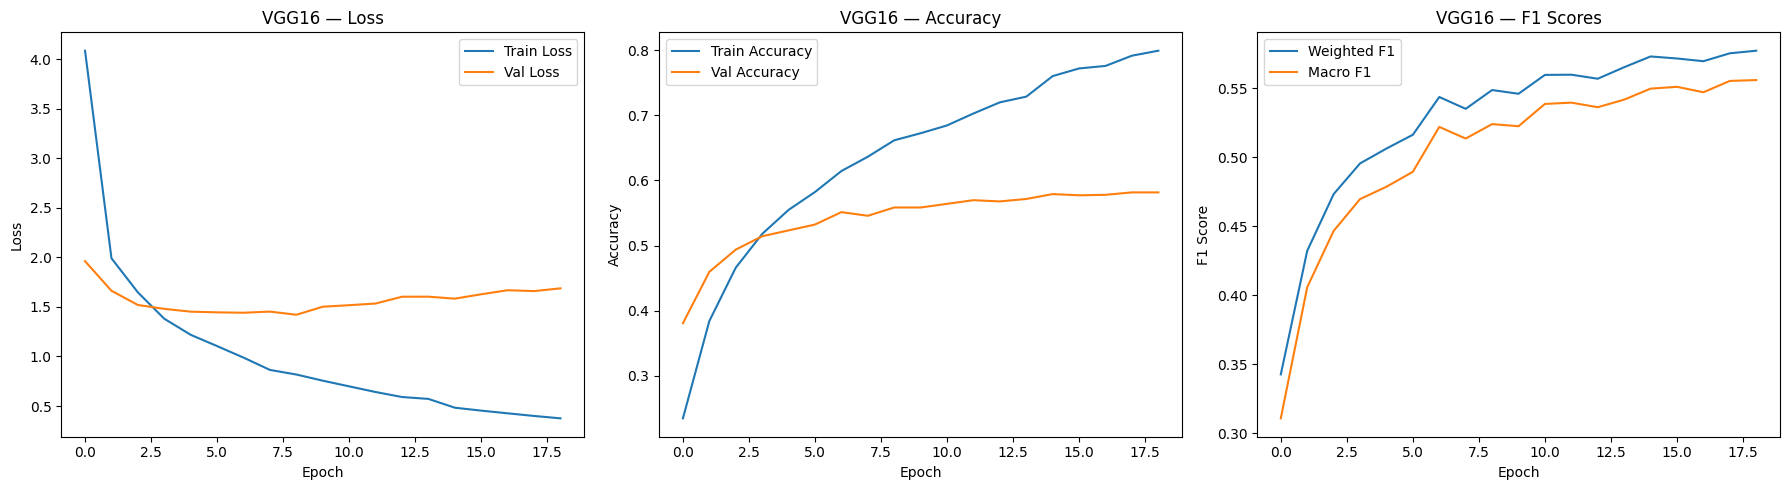

In [19]:
# Plot training curves
plot_training_history(final_history, "VGG16");

In [20]:
# Evaluate on validation set
y_true, y_pred, f1_weighted, f1_macro = evaluate_model(model_vgg, val_ds, class_names)


Validation Results:
  Weighted F1: 0.5488
  Macro F1:    0.5241

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.67      0.57      0.61       116
      Boris_Kustodiev       0.34      0.19      0.24        89
     Camille_Pissarro       0.56      0.48      0.52       124
        Childe_Hassam       0.45      0.17      0.25        77
         Claude_Monet       0.50      0.73      0.60       187
          Edgar_Degas       0.51      0.43      0.47        86
        Eugene_Boudin       0.71      0.64      0.68        78
         Gustave_Dore       0.79      0.79      0.79       106
           Ilya_Repin       0.35      0.42      0.38        76
      Ivan_Aivazovsky       0.87      0.89      0.88        81
        Ivan_Shishkin       0.68      0.62      0.65        73
  John_Singer_Sargent       0.67      0.45      0.54       110
         Marc_Chagall       0.62      0.48      0.54       107
      Martiros_Saryan       0.46 

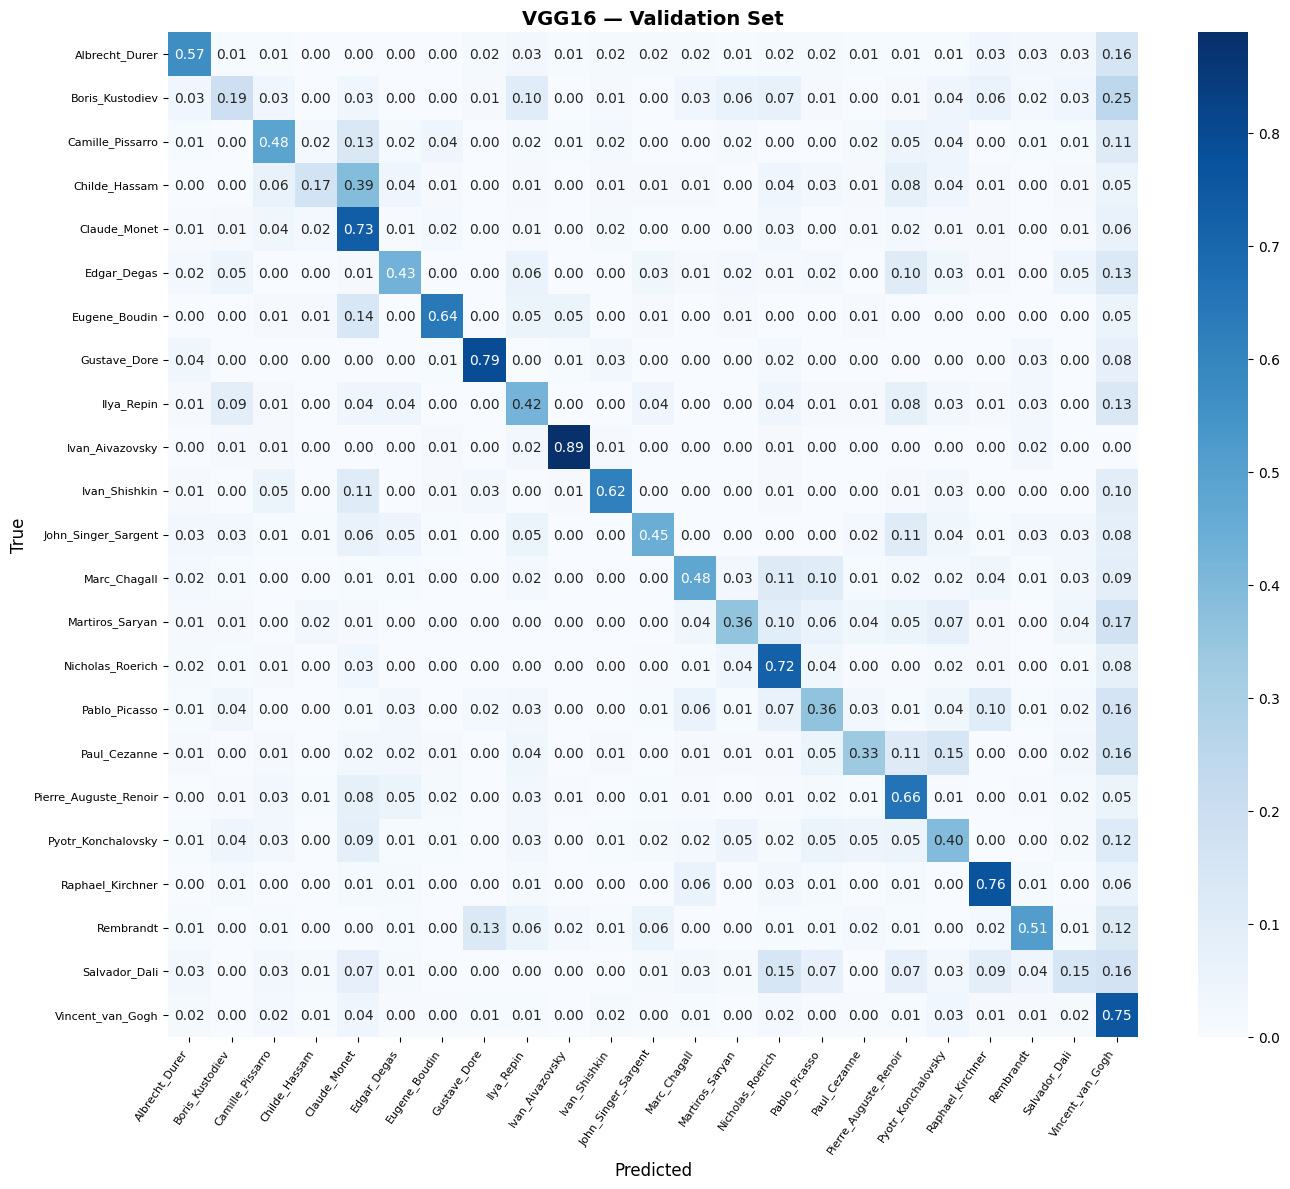

In [21]:
# Confusion matrix — shows which painters the model confuses
plot_confusion_matrix(y_true, y_pred, class_names, "VGG16 — Validation Set");

In [22]:
# Log final metrics to W&B and finish this run
wandb.log({"val_f1_weighted": f1_weighted, "val_f1_macro": f1_macro})
wandb.finish()

epoch/accuracy,▁▃▄▅▅▅▆▆▆▆▇▇▇▇█████
epoch/epoch,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇██
epoch/learning_rate,█████████████▄▄▄▄▄▁
epoch/loss,█▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch/val_accuracy,▁▄▅▆▆▆▇▇▇▇▇████████
epoch/val_f1_macro,▁▄▅▆▆▆▇▇▇▇██▇██████
epoch/val_f1_weighted,▁▄▅▆▆▆▇▇▇▇▇▇▇██████
epoch/val_loss,█▄▂▂▁▁▁▁▁▂▂▂▃▃▃▄▄▄▄
val_f1_macro,▁
val_f1_weighted,▁
epoch/accuracy,0.79943


### 2.2 ResNet50

For this model, first the backbone was frozen and only the classification head was trained. Then, the last 30 layers were unfrozen and fine-tuned at a much lower learning rate to avoid overwriting the pretrained weights. Class weights were used throughout to handle the class imbalance in the dataset.

In [23]:
# Load images from the split folders
IMG_SIZE = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int',
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int',
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int',
)

# class_names is the list of painter names, in the order Keras assigned them
class_names = train_ds.class_names
print(f"\nClasses ({len(class_names)}):")
for i, name in enumerate(class_names):
    print(f"  {i:2d}: {name}")

Found 8002 files belonging to 23 classes.
Found 2670 files belonging to 23 classes.
Found 2668 files belonging to 23 classes.

Classes (23):
   0: Albrecht_Durer
   1: Boris_Kustodiev
   2: Camille_Pissarro
   3: Childe_Hassam
   4: Claude_Monet
   5: Edgar_Degas
   6: Eugene_Boudin
   7: Gustave_Dore
   8: Ilya_Repin
   9: Ivan_Aivazovsky
  10: Ivan_Shishkin
  11: John_Singer_Sargent
  12: Marc_Chagall
  13: Martiros_Saryan
  14: Nicholas_Roerich
  15: Pablo_Picasso
  16: Paul_Cezanne
  17: Pierre_Auguste_Renoir
  18: Pyotr_Konchalovsky
  19: Raphael_Kirchner
  20: Rembrandt
  21: Salvador_Dali
  22: Vincent_van_Gogh


In [24]:
# Preprocessing & Augmentation

# ResNet50 requires its own preprocessing (BGR mean subtraction → roughly [-1, 1]).
# Augmentation MUST happen BEFORE preprocessing, on raw [0, 255] values,
# so that contrast/sharpness operations work on natural pixel ranges.

augmentation_layer = keras.Sequential([
    layers.RandomZoom(0.15),          
    layers.RandomFlip("horizontal"),  
    layers.RandomContrast(0.1),       
    layers.RandomSharpness(0.1),     
], name="augmentation")

def augment_and_preprocess(images, labels):
    """For training: augment on [0,255] first, then apply ResNet preprocessing."""
    images = tf.cast(images, tf.float32)
    images = augmentation_layer(images, training=True)
    images = resnet_preprocess(images)
    return images, labels

def preprocess_only(images, labels):
    """For val/test: only ResNet preprocessing, no augmentation."""
    images = tf.cast(images, tf.float32)
    images = resnet_preprocess(images)
    return images, labels

In [25]:
# Augmented training set
augmented_train_ds = (train_ds.map(augment_and_preprocess, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE))

# Non-augmented training set (used for train evaluation only)
train_ds2 = (train_ds.map(preprocess_only, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE))

In [26]:
val_ds2 = (val_ds.map(preprocess_only, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE))
test_ds2 = (test_ds.map(preprocess_only, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE))

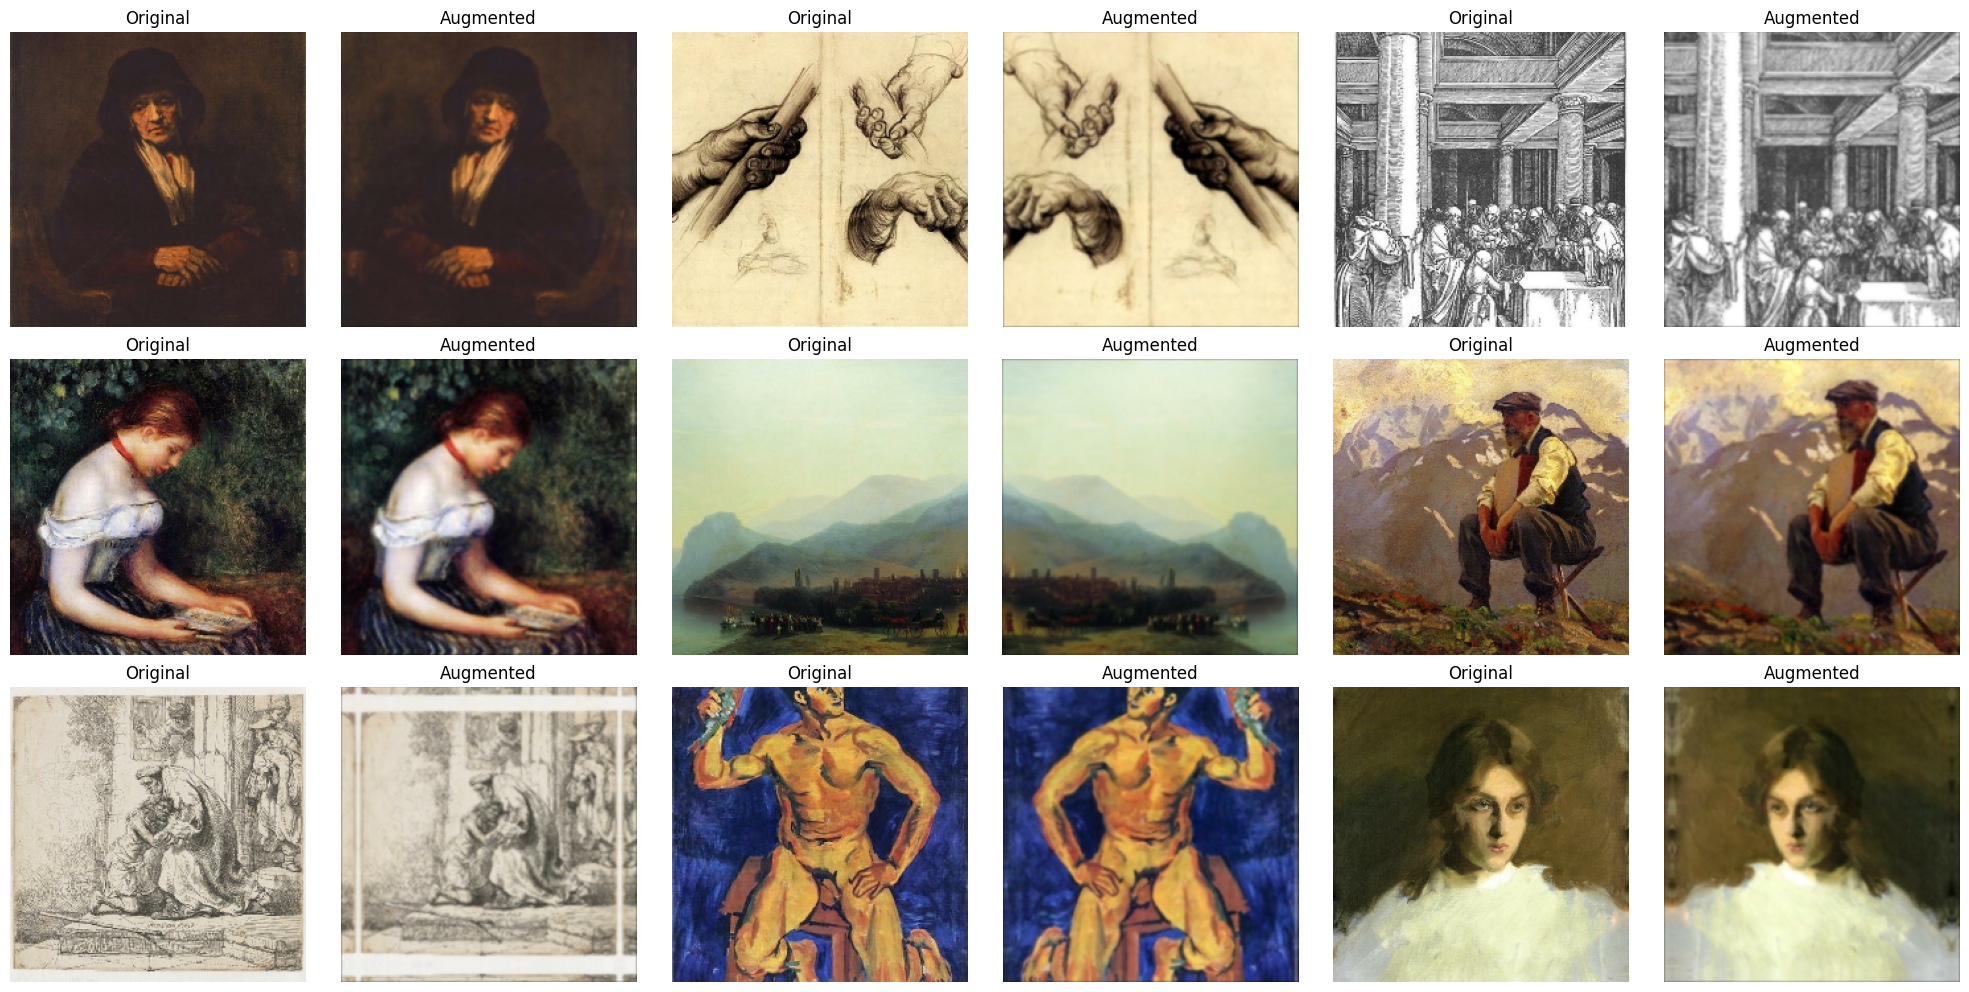

In [27]:
# Visualize augmentation 
plt.figure(figsize=(20, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax_left = plt.subplot(3, 6, i*2 + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Original")
        plt.axis("off")

        paint_batch = tf.expand_dims(tf.cast(images[i], tf.float32), axis=0)
        aug_batch   = augmentation_layer(paint_batch, training=True)
        aug_image   = tf.clip_by_value(aug_batch[0], 0.0, 255.0)

        ax_right = plt.subplot(3, 6, i*2 + 2)
        plt.imshow(aug_image.numpy().astype("uint8"))
        plt.title("Augmented")
        plt.axis("off")

plt.tight_layout()
plt.show()

#### 2.2.1 Class weights

In [28]:
# Count how many images each painter has in the training set
train_labels = []
for _, labels in train_ds2:
    train_labels.extend(labels.numpy())
train_labels = np.array(train_labels)

label_counts = Counter(train_labels)
total_samples = len(train_labels)

# Compute weights: rarer classes get higher weights
# Formula: total_samples / (num_classes * count_for_this_class)
class_weights = {
    cls: total_samples / (NUM_CLASSES * count)
    for cls, count in label_counts.items()
}

print(f"{'Painter':30s}  {'Samples':>8s}  {'Weight':>8s}")
print("-" * 50)
for cls_idx in sorted(class_weights.keys()):
    print(f"{class_names[cls_idx]:30s}  {label_counts[cls_idx]:8d}  {class_weights[cls_idx]:8.3f}")

Painter                          Samples    Weight
--------------------------------------------------
Albrecht_Durer                       348     1.000
Boris_Kustodiev                      266     1.308
Camille_Pissarro                     373     0.933
Childe_Hassam                        231     1.506
Claude_Monet                         560     0.621
Edgar_Degas                          257     1.354
Eugene_Boudin                        233     1.493
Gustave_Dore                         317     1.098
Ilya_Repin                           227     1.533
Ivan_Aivazovsky                      242     1.438
Ivan_Shishkin                        218     1.596
John_Singer_Sargent                  329     1.057
Marc_Chagall                         322     1.080
Martiros_Saryan                      242     1.438
Nicholas_Roerich                     764     0.455
Pablo_Picasso                        320     1.087
Paul_Cezanne                         244     1.426
Pierre_Auguste_Renoir          

#### 2.2.2 Create model

In [29]:
wandb.init(
    project="wikiart-pre_trained",
    name="ResNet50_Aug_frozen",
    id=wandb.util.generate_id(),
    config={
        "architecture": "ResNet50",
        "phase": "frozen",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "dense_units": 256,
        "dropout": 0.5,
        "l2": 1e-4,
        "augmentation": "zoom+flip+contrast+sharpness",
        "optimizer": "adam",
        "learning_rate": 0.001,
    }
)

In [30]:
# Load ResNet50 pretrained on ImageNet, without its top classification head
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze entire base - only train the custom head
resnet_base.trainable = False

# Build the classification head
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = resnet_base(inputs, training=False)   # training=False keeps BatchNorm in inference mode
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model_resnet = Model(inputs, outputs, name="ResNet50_WikiArt")
model_resnet.summary()

# Compile
model_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_WikiArt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,118,167 (92.00 MB)

 Trainable params: 530,455 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [31]:
# Train the model
# max epochs = 100, but EarlyStopping will stop it sooner if val_loss stops improving

history = model_resnet.fit(
    augmented_train_ds,
    validation_data=val_ds2,
    epochs=100,
    verbose=2,
    class_weight=class_weights,
    callbacks=[
        # Stop training if val_loss doesn't improve for 10 epochs
        # restore_best_weights=True means we keep the best model, not the last one
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        # Halve the learning rate if val_loss doesn't improve for 5 epochs
        # This lets the model make finer adjustments as it gets closer to a good solution
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        F1Callback(val_ds2),
        # Log metrics to W&B automatically every epoch
        WandbMetricsLogger(),
    ],
)

Epoch 1/100
 — val_f1_weighted: 0.5812 — val_f1_macro: 0.5618
126/126 - 119s - 943ms/step - accuracy: 0.3673 - loss: 2.1603 - val_accuracy: 0.5764 - val_loss: 1.4459 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.5812 - val_f1_macro: 0.5618
Epoch 2/100
 — val_f1_weighted: 0.6263 — val_f1_macro: 0.6042
126/126 - 75s - 593ms/step - accuracy: 0.5371 - loss: 1.5119 - val_accuracy: 0.6236 - val_loss: 1.2908 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.6263 - val_f1_macro: 0.6042
Epoch 3/100
 — val_f1_weighted: 0.6600 — val_f1_macro: 0.6407
126/126 - 74s - 588ms/step - accuracy: 0.5906 - loss: 1.3133 - val_accuracy: 0.6528 - val_loss: 1.1802 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.6600 - val_f1_macro: 0.6407
Epoch 4/100
 — val_f1_weighted: 0.6485 — val_f1_macro: 0.6231
126/126 - 74s - 590ms/step - accuracy: 0.6226 - loss: 1.1944 - val_accuracy: 0.6404 - val_loss: 1.1860 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.6485 - val_f1_macro: 0.6231
Epoch 5/100
 — val_f1_weighted:

In [32]:
train_results = evaluate_model(model_resnet, train_ds2, class_names, "Train")
val_results   = evaluate_model(model_resnet, val_ds2,   class_names, "Validation")


Train Results:
  Weighted F1: 0.7907
  Macro F1:    0.7858

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.95      0.67      0.79       348
      Boris_Kustodiev       0.81      0.62      0.70       266
     Camille_Pissarro       0.78      0.64      0.70       373
        Childe_Hassam       0.68      0.77      0.72       231
         Claude_Monet       0.71      0.80      0.76       560
          Edgar_Degas       0.89      0.72      0.80       257
        Eugene_Boudin       0.86      0.84      0.85       233
         Gustave_Dore       0.86      0.97      0.91       317
           Ilya_Repin       0.49      0.91      0.64       227
      Ivan_Aivazovsky       0.92      0.96      0.94       242
        Ivan_Shishkin       0.90      0.77      0.83       218
  John_Singer_Sargent       0.78      0.87      0.82       329
         Marc_Chagall       0.91      0.78      0.84       322
      Martiros_Saryan       0.66      

#### 2.2.3 Evaluate model

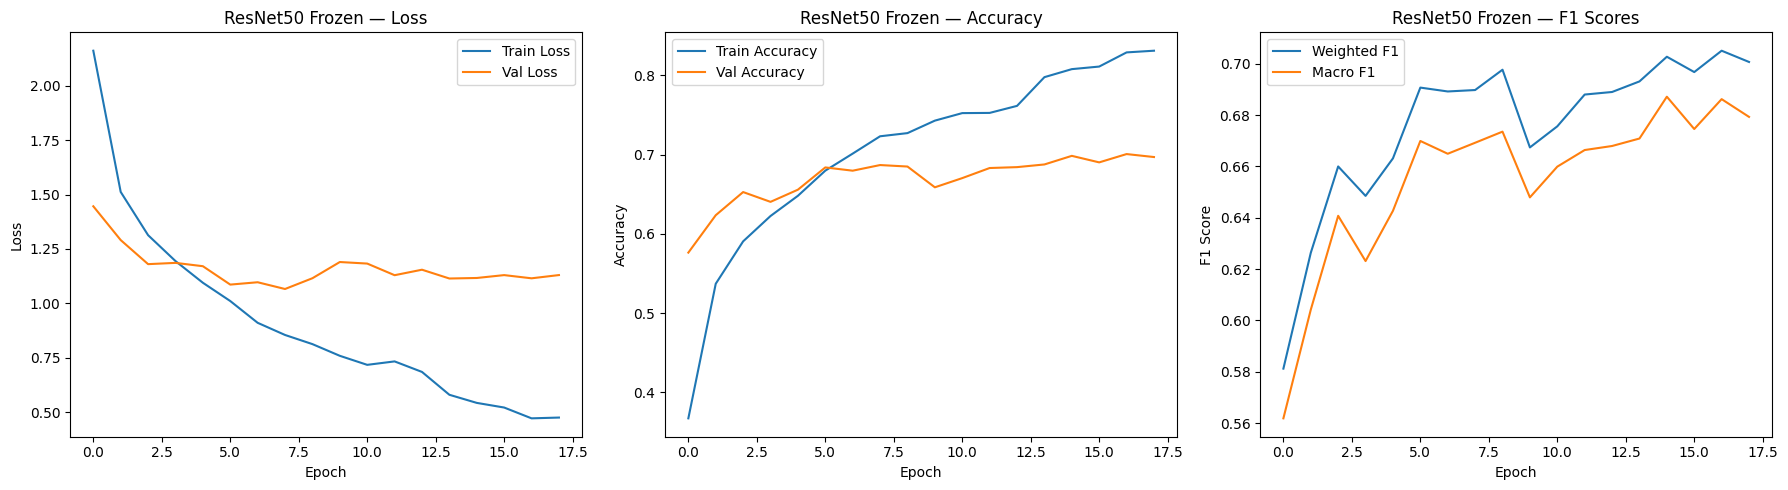

In [33]:
plot_training_history(history, "ResNet50 Frozen");

In [35]:
y_true, y_pred, f1_weighted, f1_macro = evaluate_model(model_resnet, val_ds2, class_names)


Validation Results:
  Weighted F1: 0.6898
  Macro F1:    0.6692

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.94      0.56      0.70       116
      Boris_Kustodiev       0.61      0.48      0.54        89
     Camille_Pissarro       0.72      0.57      0.64       124
        Childe_Hassam       0.57      0.68      0.62        77
         Claude_Monet       0.65      0.71      0.68       187
          Edgar_Degas       0.70      0.56      0.62        86
        Eugene_Boudin       0.81      0.72      0.76        78
         Gustave_Dore       0.83      0.93      0.88       106
           Ilya_Repin       0.37      0.76      0.50        76
      Ivan_Aivazovsky       0.85      0.95      0.90        81
        Ivan_Shishkin       0.80      0.53      0.64        73
  John_Singer_Sargent       0.63      0.78      0.70       110
         Marc_Chagall       0.79      0.61      0.69       107
      Martiros_Saryan       0.48 

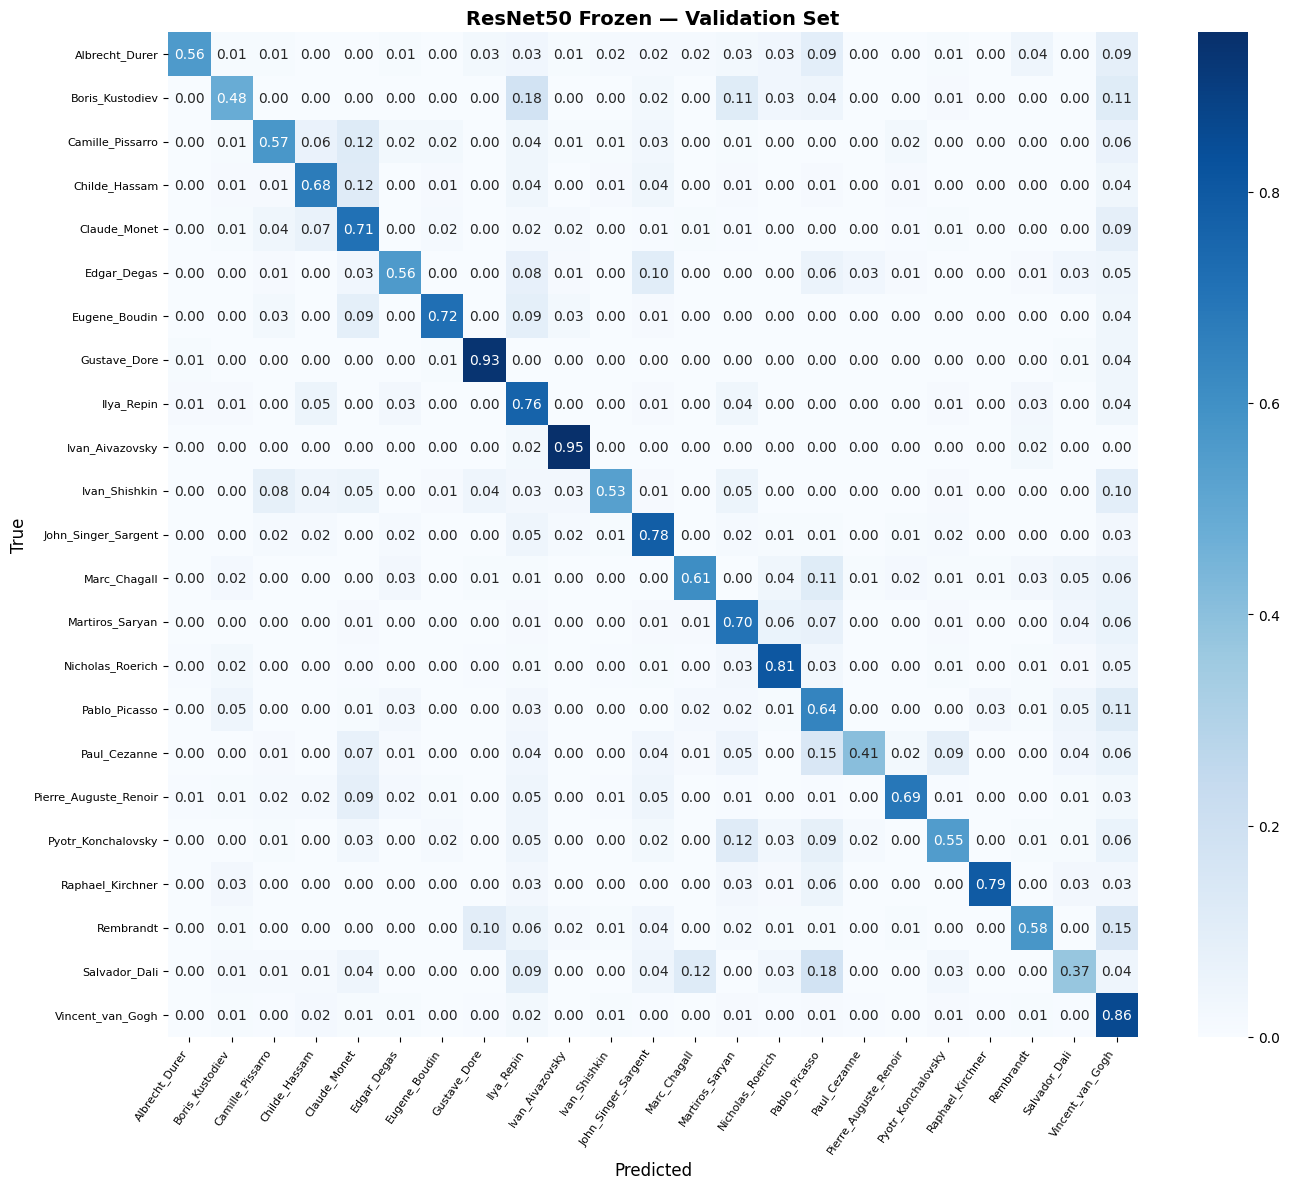

In [36]:
plot_confusion_matrix(y_true, y_pred, class_names, "ResNet50 Frozen — Validation Set");

In [37]:
wandb.log({"val_f1_weighted": f1_weighted, "val_f1_macro": f1_macro})
wandb.finish()

epoch/accuracy,▁▄▄▅▅▆▆▆▆▇▇▇▇▇████
epoch/epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
epoch/learning_rate,████████████▃▃▃▃▃▁
epoch/loss,█▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
epoch/val_accuracy,▁▄▅▅▅▇▇▇▇▆▆▇▇▇█▇██
epoch/val_f1_macro,▁▃▅▄▆▇▇▇▇▆▆▇▇▇█▇██
epoch/val_f1_weighted,▁▄▅▅▆▇▇▇█▆▆▇▇▇████
epoch/val_loss,█▅▃▃▃▁▂▁▂▃▃▂▃▂▂▂▂▂
val_f1_macro,▁
val_f1_weighted,▁
epoch/accuracy,0.83117


#### 2.2.4 Fine tuning

In [38]:
# Unfreeze the last 30 layers of ResNet50 and continue training at a very low
# learning rate. This lets the backbone adapt to painting-specific features
# (brushstrokes, colour palette, composition) without destroying ImageNet weights.
 
wandb.init(
    project="wikiart-pre_trained",
    name="2ResNet50_Aug_finetuned",
    id=wandb.util.generate_id(),
    config={
        "architecture": "ResNet50",
        "phase": "fine-tuned",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "dense_units": 256,
        "dropout": 0.5,
        "l2": 1e-4,
        "unfrozen_layers": 30,
        "augmentation": "zoom+flip+contrast+sharpness",
        "optimizer": "adam",
        "learning_rate": 5e-6,
    }
)

In [41]:
# 1. Unfreeze last 30 layers only
resnet_base.trainable = False
for layer in resnet_base.layers[-30:]:
    layer.trainable = True
 
# 2. Recompile — gotta recompile after changing trainable state
model_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),  # much lower than frozen one ran before this
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
# Continue training the same model (head weights from frozen one ran before this are preserved)
history_ft = model_resnet.fit(
    augmented_train_ds,
    validation_data=val_ds2,
    epochs=100,
    verbose=2,
    class_weight=class_weights,
    callbacks=[
        F1Callback(val_ds2),
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        WandbMetricsLogger(),
    ],
)

Epoch 1/100
 — val_f1_weighted: 0.6819 — val_f1_macro: 0.6629
126/126 - 115s - 915ms/step - accuracy: 0.6380 - loss: 1.1461 - val_accuracy: 0.6794 - val_loss: 1.1298 - val_f1_weighted: 0.6819 - val_f1_macro: 0.6629 - learning_rate: 5.0000e-06
Epoch 2/100
 — val_f1_weighted: 0.6813 — val_f1_macro: 0.6618
126/126 - 75s - 599ms/step - accuracy: 0.6932 - loss: 0.9351 - val_accuracy: 0.6787 - val_loss: 1.1394 - val_f1_weighted: 0.6813 - val_f1_macro: 0.6618 - learning_rate: 5.0000e-06
Epoch 3/100
 — val_f1_weighted: 0.6819 — val_f1_macro: 0.6628
126/126 - 75s - 599ms/step - accuracy: 0.7267 - loss: 0.8322 - val_accuracy: 0.6790 - val_loss: 1.1228 - val_f1_weighted: 0.6819 - val_f1_macro: 0.6628 - learning_rate: 5.0000e-06
Epoch 4/100
 — val_f1_weighted: 0.6892 — val_f1_macro: 0.6691
126/126 - 75s - 595ms/step - accuracy: 0.7406 - loss: 0.7725 - val_accuracy: 0.6861 - val_loss: 1.0989 - val_f1_weighted: 0.6892 - val_f1_macro: 0.6691 - learning_rate: 5.0000e-06
Epoch 5/100
 — val_f1_weighted:

In [43]:
train_results_ft = evaluate_model(model_resnet, train_ds2, class_names, "Train")
val_results_ft   = evaluate_model(model_resnet, val_ds2,   class_names, "Validation")


Train Results:
  Weighted F1: 0.8494
  Macro F1:    0.8506

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.92      0.84      0.88       348
      Boris_Kustodiev       0.92      0.74      0.82       266
     Camille_Pissarro       0.81      0.74      0.77       373
        Childe_Hassam       0.69      0.89      0.78       231
         Claude_Monet       0.78      0.83      0.80       560
          Edgar_Degas       0.94      0.84      0.89       257
        Eugene_Boudin       0.94      0.88      0.90       233
         Gustave_Dore       0.92      0.97      0.95       317
           Ilya_Repin       0.73      0.92      0.82       227
      Ivan_Aivazovsky       0.91      1.00      0.95       242
        Ivan_Shishkin       0.85      0.89      0.87       218
  John_Singer_Sargent       0.93      0.86      0.90       329
         Marc_Chagall       0.98      0.75      0.85       322
      Martiros_Saryan       0.60      

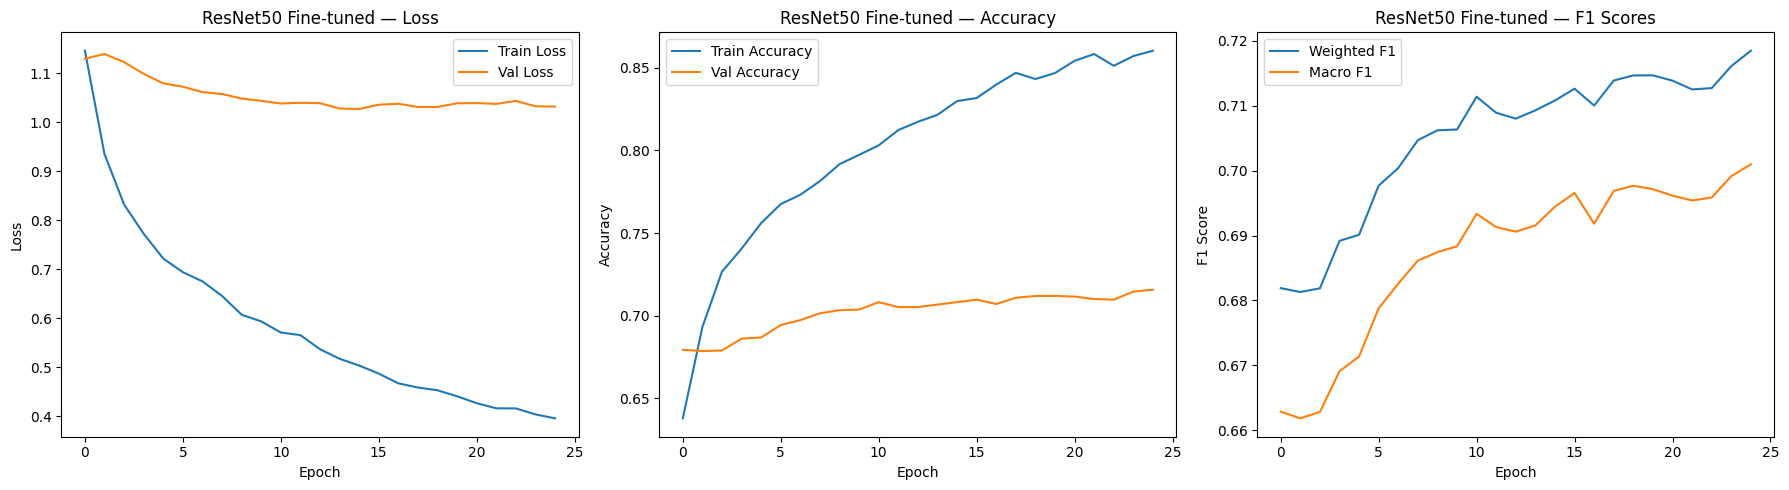

In [44]:
plot_training_history(history_ft, "ResNet50 Fine-tuned");

In [48]:
y_true, y_pred, f1_weighted, f1_macro = val_results_ft

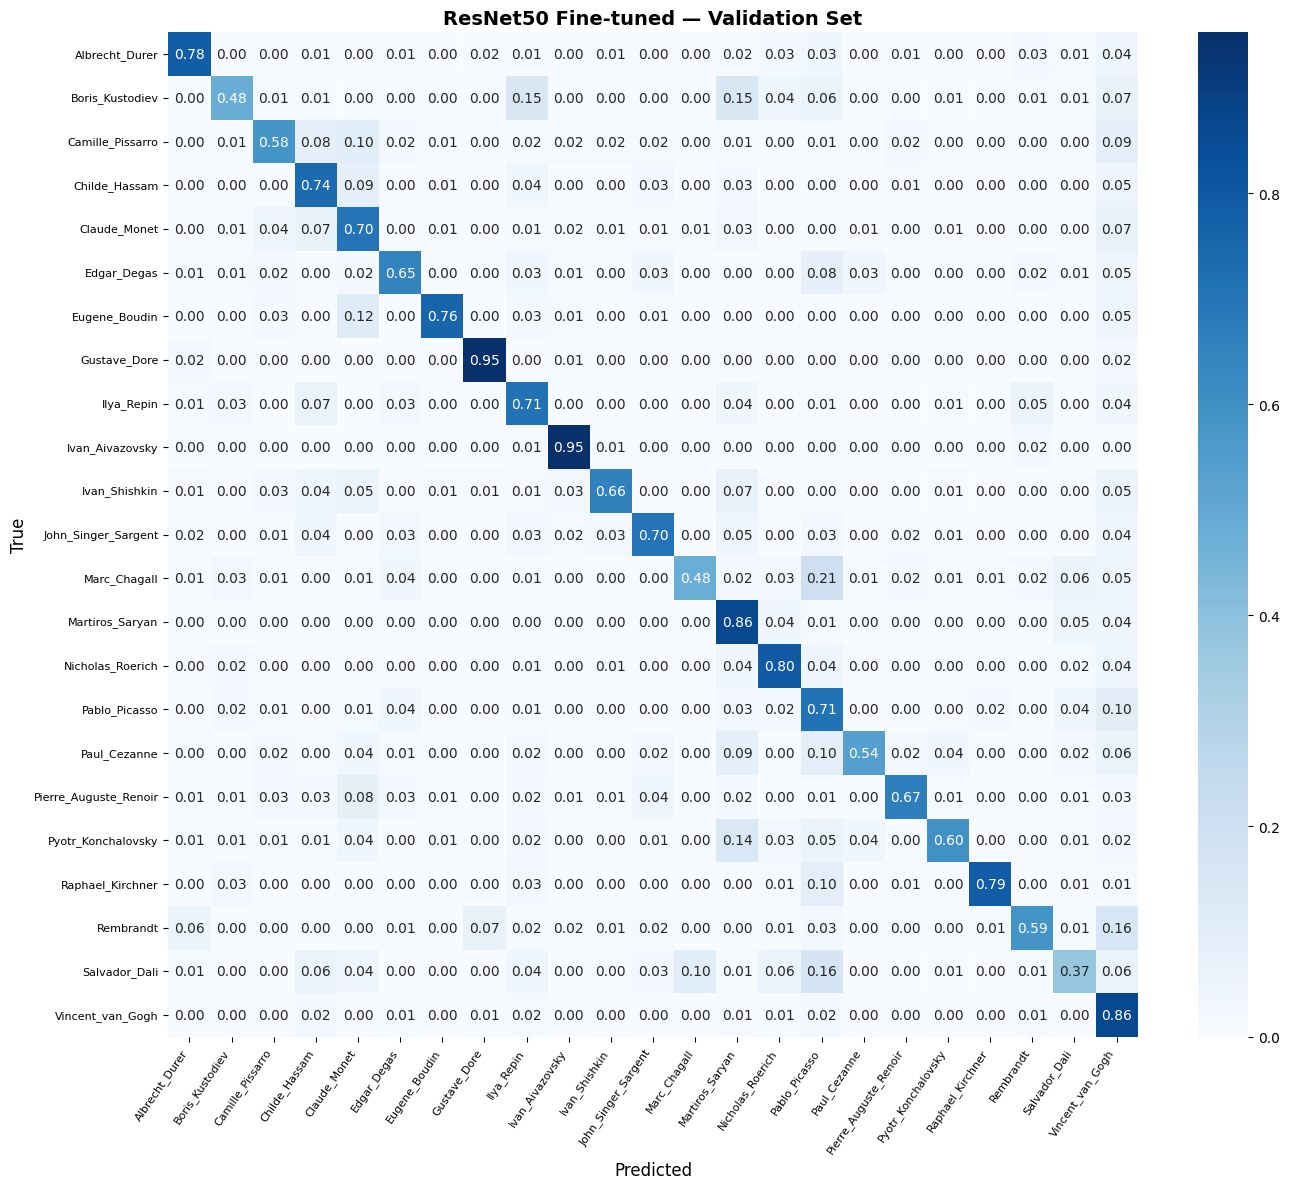

In [51]:
plot_confusion_matrix(y_true, y_pred, class_names, "ResNet50 Fine-tuned — Validation Set");

In [52]:
wandb.log({"val_f1_weighted": f1_weighted, "val_f1_macro": f1_macro})
wandb.finish()

epoch/accuracy,▁▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇█▇██████
epoch/epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
epoch/learning_rate,███████████████████▃▃▃▃▃▁
epoch/loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
epoch/val_accuracy,▁▁▁▂▃▄▅▅▆▆▇▆▆▆▇▇▆▇▇▇▇▇▇██
epoch/val_f1_macro,▁▁▁▂▃▄▅▅▆▆▇▆▆▆▇▇▆▇▇▇▇▇▇██
epoch/val_f1_weighted,▁▁▁▂▃▄▅▅▆▆▇▆▆▆▇▇▆▇▇▇▇▇▇██
epoch/val_loss,▇█▇▅▄▄▃▃▂▂▂▂▂▁▁▂▂▁▁▂▂▂▂▁▁
val_f1_macro,▁
val_f1_weighted,▁
epoch/accuracy,0.86028


#### 2.2.5 ResNet50 + L2

In [53]:
wandb.init(
    project="wikiart-pre_trained",
    name="ResNet50_L2",
    id=wandb.util.generate_id(),
    config={
        "architecture": "ResNet50",
        "phase": "frozen",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "dense_units": 256,
        "dropout": 0.5,
        "l2": 1e-4,
        "augmentation": "zoom+flip+contrast+sharpness",
        "optimizer": "adam",
        "learning_rate": 0.001,
    }
)

In [54]:
# Load ResNet50 pretrained on ImageNet, without its top classification head
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze entire base - only train the custom head
resnet_base.trainable = False

# Build the classification head
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = resnet_base(inputs, training=False)   # training=False keeps BatchNorm in inference mode
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model_resnet_L2 = Model(inputs, outputs, name="ResNet50_WikiArt")
model_resnet_L2.summary()

# Compile
model_resnet_L2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "ResNet50_WikiArt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,118,167 (92.00 MB)

 Trainable params: 530,455 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [55]:
history = model_resnet_L2.fit(
    augmented_train_ds,
    validation_data=val_ds2,
    epochs=100,
    verbose=2,
    class_weight=class_weights,
    callbacks=[
        # Stop training if val_loss doesn't improve for 10 epochs
        # restore_best_weights=True means we keep the best model, not the last one
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        # Halve the learning rate if val_loss doesn't improve for 5 epochs
        # This lets the model make finer adjustments as it gets closer to a good solution
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        F1Callback(val_ds2),
        # Log metrics to W&B automatically every epoch
        WandbMetricsLogger(),
    ],
)

Epoch 1/100
 — val_f1_weighted: 0.5762 — val_f1_macro: 0.5594
126/126 - 103s - 815ms/step - accuracy: 0.3527 - loss: 2.2814 - val_accuracy: 0.5719 - val_loss: 1.5448 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.5762 - val_f1_macro: 0.5594
Epoch 2/100
 — val_f1_weighted: 0.6289 — val_f1_macro: 0.6072
126/126 - 75s - 591ms/step - accuracy: 0.5234 - loss: 1.6216 - val_accuracy: 0.6288 - val_loss: 1.3198 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.6289 - val_f1_macro: 0.6072
Epoch 3/100
 — val_f1_weighted: 0.6469 — val_f1_macro: 0.6236
126/126 - 76s - 604ms/step - accuracy: 0.5835 - loss: 1.3860 - val_accuracy: 0.6442 - val_loss: 1.2637 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.6469 - val_f1_macro: 0.6236
Epoch 4/100
 — val_f1_weighted: 0.6416 — val_f1_macro: 0.6212
126/126 - 76s - 604ms/step - accuracy: 0.6273 - loss: 1.2401 - val_accuracy: 0.6348 - val_loss: 1.2419 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.6416 - val_f1_macro: 0.6212
Epoch 5/100
 — val_f1_weighted:

In [56]:
train_results = evaluate_model(model_resnet_L2, train_ds2, class_names, "Train")
val_results   = evaluate_model(model_resnet_L2, val_ds2,   class_names, "Validation")


Train Results:
  Weighted F1: 0.8098
  Macro F1:    0.8058

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.90      0.77      0.83       348
      Boris_Kustodiev       0.82      0.66      0.73       266
     Camille_Pissarro       0.81      0.67      0.74       373
        Childe_Hassam       0.68      0.77      0.72       231
         Claude_Monet       0.73      0.84      0.78       560
          Edgar_Degas       0.72      0.88      0.79       257
        Eugene_Boudin       0.91      0.85      0.88       233
         Gustave_Dore       0.86      0.98      0.92       317
           Ilya_Repin       0.69      0.85      0.76       227
      Ivan_Aivazovsky       0.85      0.98      0.91       242
        Ivan_Shishkin       0.85      0.81      0.83       218
  John_Singer_Sargent       0.92      0.76      0.84       329
         Marc_Chagall       0.99      0.64      0.78       322
      Martiros_Saryan       0.54      

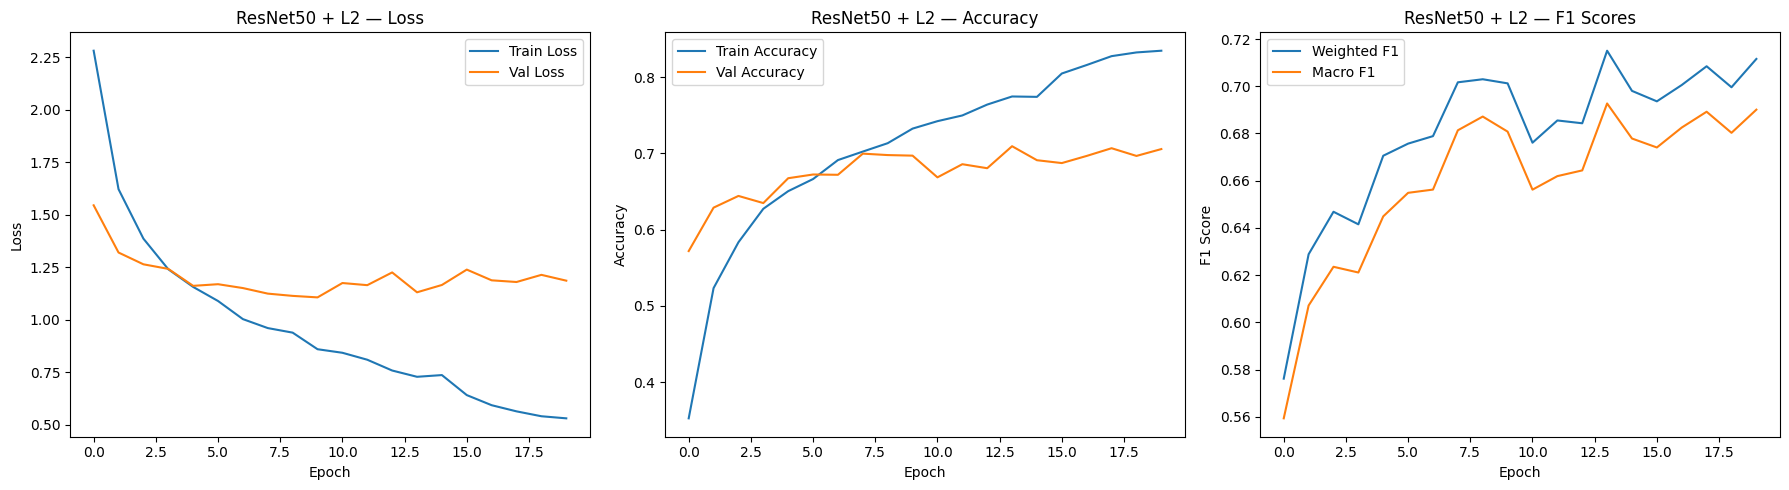

In [57]:
plot_training_history(history, "ResNet50 + L2");

In [59]:
y_true, y_pred, f1_weighted, f1_macro = evaluate_model(model_resnet_L2, val_ds2, class_names)


Validation Results:
  Weighted F1: 0.7012
  Macro F1:    0.6808

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.92      0.76      0.83       116
      Boris_Kustodiev       0.64      0.46      0.54        89
     Camille_Pissarro       0.71      0.58      0.64       124
        Childe_Hassam       0.52      0.69      0.60        77
         Claude_Monet       0.70      0.72      0.71       187
          Edgar_Degas       0.46      0.76      0.57        86
        Eugene_Boudin       0.89      0.73      0.80        78
         Gustave_Dore       0.81      0.93      0.87       106
           Ilya_Repin       0.51      0.59      0.55        76
      Ivan_Aivazovsky       0.80      0.96      0.88        81
        Ivan_Shishkin       0.81      0.60      0.69        73
  John_Singer_Sargent       0.79      0.58      0.67       110
         Marc_Chagall       0.94      0.44      0.60       107
      Martiros_Saryan       0.38 

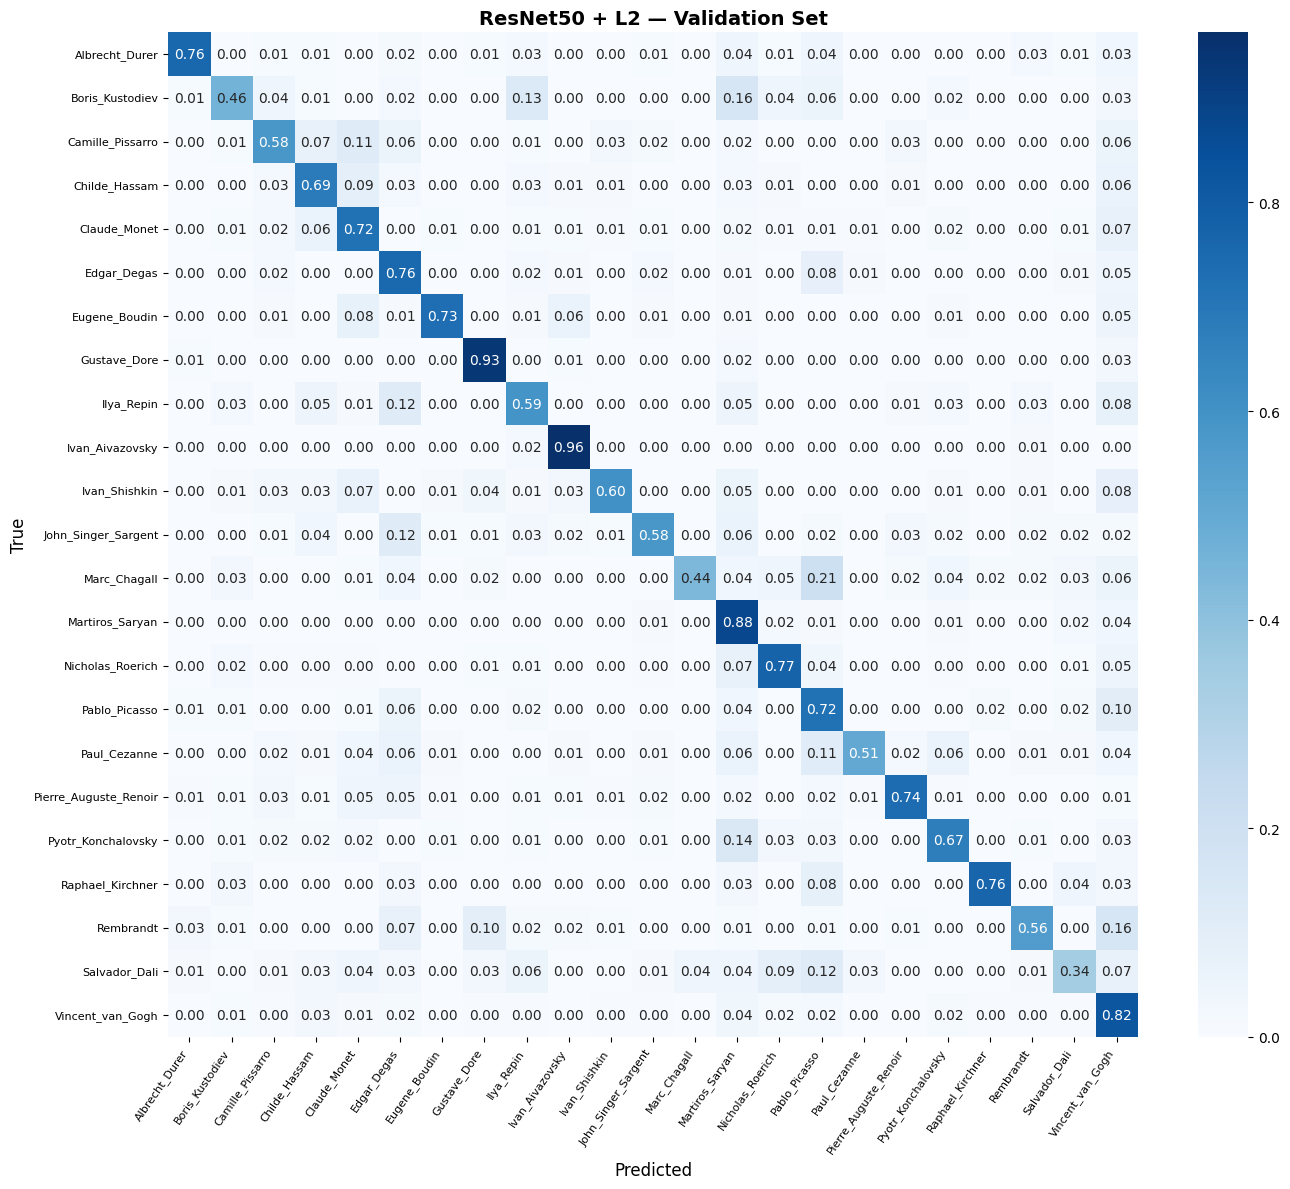

In [60]:
plot_confusion_matrix(y_true, y_pred, class_names, "ResNet50 + L2 — Validation Set");

In [61]:
wandb.log({"val_f1_weighted": f1_weighted, "val_f1_macro": f1_macro})
wandb.finish()

epoch/accuracy,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇█████
epoch/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch/learning_rate,██████████████▃▃▃▃▃▁
epoch/loss,█▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
epoch/val_accuracy,▁▄▅▄▆▆▆█▇▇▆▇▇█▇▇▇█▇█
epoch/val_f1_macro,▁▄▄▄▅▆▆▇█▇▆▆▇█▇▇▇█▇█
epoch/val_f1_weighted,▁▄▅▄▆▆▆▇▇▇▆▇▆█▇▇▇█▇█
epoch/val_loss,█▄▄▃▂▂▂▁▁▁▂▂▃▁▂▃▂▂▃▂
val_f1_macro,▁
val_f1_weighted,▁
epoch/accuracy,0.83454


#### 2.2.6 Fine tuning (ResNet 50 + L2)

In [62]:
# Unfreeze the last 30 layers of ResNet50 and continue training at a very low
# learning rate. This lets the backbone adapt to painting-specific features
# (brushstrokes, colour palette, composition) without destroying ImageNet weights.
 
wandb.init(
    project="wikiart-pre_trained",
    name="ResNet50_L2_finetuned",
    id=wandb.util.generate_id(),
    config={
        "architecture": "ResNet50_L2_ft",
        "phase": "fine-tuned",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "dense_units": 256,
        "dropout": 0.5,
        "l2": 1e-4,
        "unfrozen_layers": 30,
        "augmentation": "zoom+flip+contrast+sharpness",
        "optimizer": "adam",
        "learning_rate": 5e-6,
    }
)

In [63]:
# 1. Unfreeze last 30 layers only
resnet_base.trainable = False
for layer in resnet_base.layers[-30:]:
    layer.trainable = True
 
# 2. Recompile — gotta recompile after changing trainable state
model_resnet_L2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),  # much lower than frozen one ran before this
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [64]:
# Continue training the same model (head weights from frozen one ran before this are preserved)
history_ft = model_resnet_L2.fit(
    augmented_train_ds,
    validation_data=val_ds2,
    epochs=100,
    verbose=2,
    class_weight=class_weights,
    callbacks=[
        F1Callback(val_ds2),
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        WandbMetricsLogger(),
    ],
)

Epoch 1/100
 — val_f1_weighted: 0.6793 — val_f1_macro: 0.6619
126/126 - 113s - 897ms/step - accuracy: 0.6472 - loss: 1.1452 - val_accuracy: 0.6757 - val_loss: 1.1917 - val_f1_weighted: 0.6793 - val_f1_macro: 0.6619 - learning_rate: 5.0000e-06
Epoch 2/100
 — val_f1_weighted: 0.6745 — val_f1_macro: 0.6565
126/126 - 75s - 598ms/step - accuracy: 0.7072 - loss: 0.9434 - val_accuracy: 0.6708 - val_loss: 1.1998 - val_f1_weighted: 0.6745 - val_f1_macro: 0.6565 - learning_rate: 5.0000e-06
Epoch 3/100
 — val_f1_weighted: 0.6817 — val_f1_macro: 0.6630
126/126 - 75s - 599ms/step - accuracy: 0.7312 - loss: 0.8393 - val_accuracy: 0.6779 - val_loss: 1.1803 - val_f1_weighted: 0.6817 - val_f1_macro: 0.6630 - learning_rate: 5.0000e-06
Epoch 4/100
 — val_f1_weighted: 0.6898 — val_f1_macro: 0.6718
126/126 - 76s - 604ms/step - accuracy: 0.7557 - loss: 0.7769 - val_accuracy: 0.6858 - val_loss: 1.1658 - val_f1_weighted: 0.6898 - val_f1_macro: 0.6718 - learning_rate: 5.0000e-06
Epoch 5/100
 — val_f1_weighted:

In [65]:
train_results_ft = evaluate_model(model_resnet_L2, train_ds2, class_names, "Train")
val_results_ft   = evaluate_model(model_resnet_L2, val_ds2,   class_names, "Validation")


Train Results:
  Weighted F1: 0.8730
  Macro F1:    0.8756

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.95      0.83      0.89       348
      Boris_Kustodiev       0.94      0.77      0.85       266
     Camille_Pissarro       0.84      0.78      0.81       373
        Childe_Hassam       0.70      0.92      0.79       231
         Claude_Monet       0.81      0.84      0.82       560
          Edgar_Degas       0.96      0.88      0.92       257
        Eugene_Boudin       0.99      0.85      0.91       233
         Gustave_Dore       0.91      0.99      0.95       317
           Ilya_Repin       0.79      0.90      0.84       227
      Ivan_Aivazovsky       0.94      1.00      0.97       242
        Ivan_Shishkin       0.86      0.87      0.86       218
  John_Singer_Sargent       0.98      0.86      0.92       329
         Marc_Chagall       0.99      0.83      0.91       322
      Martiros_Saryan       0.60      

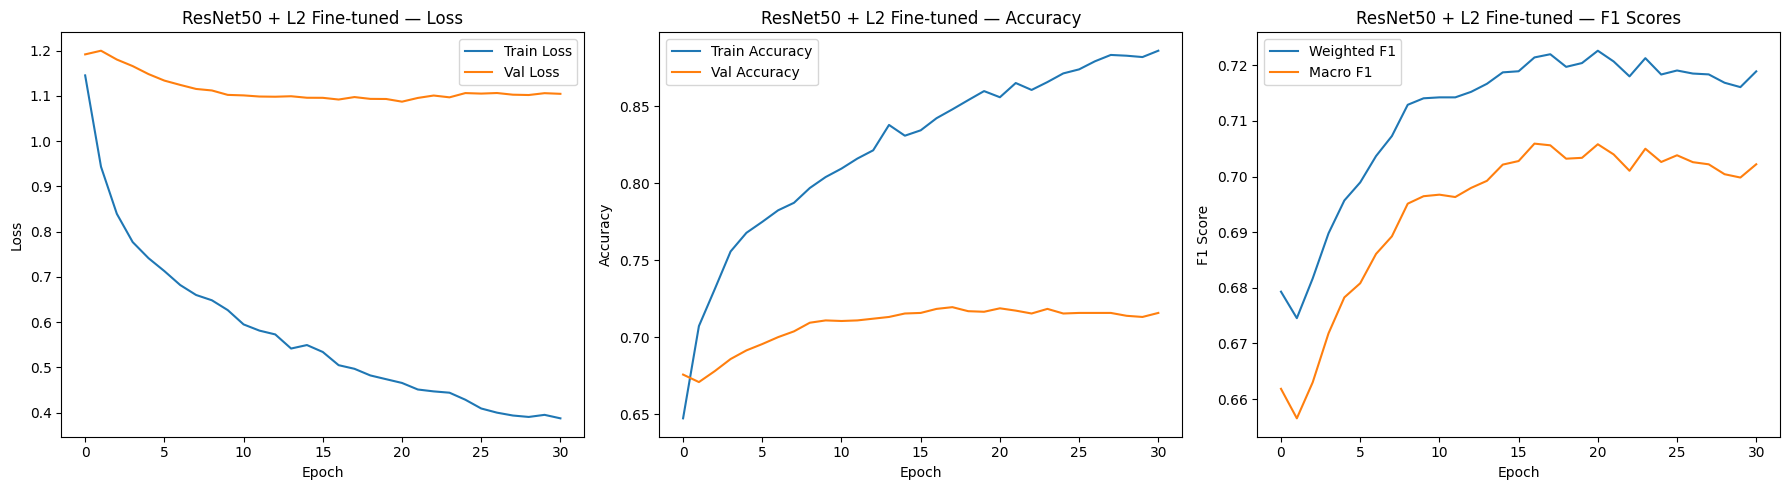

In [66]:
plot_training_history(history_ft, "ResNet50 + L2 Fine-tuned");

In [67]:
y_true, y_pred, f1_weighted, f1_macro = val_results_ft

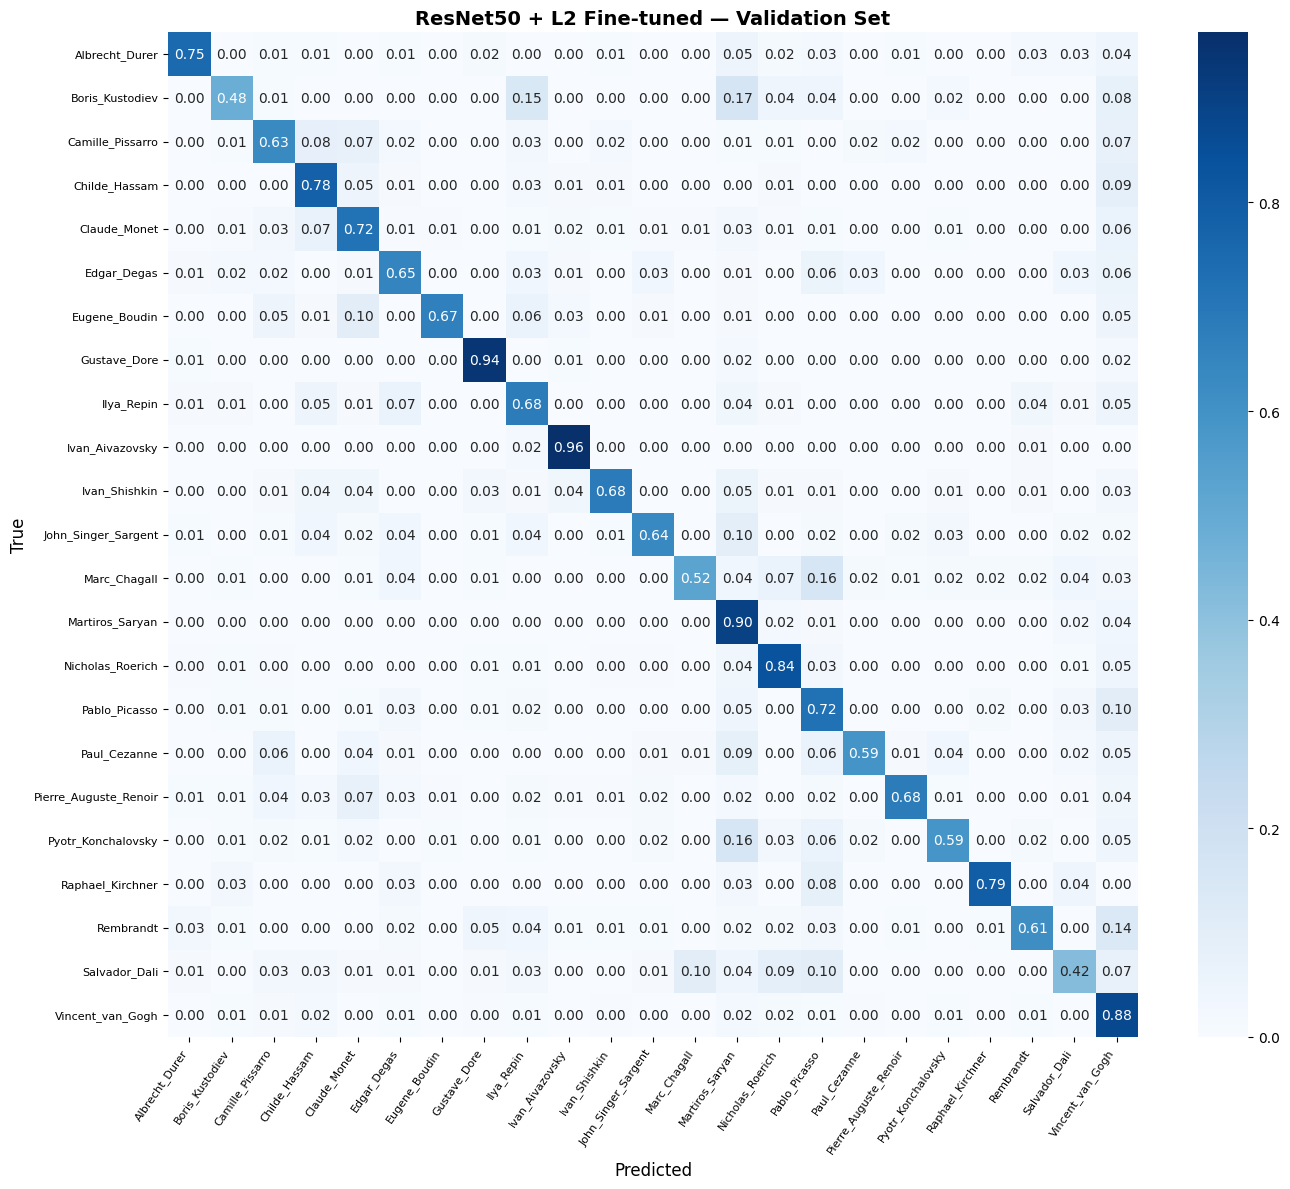

In [68]:
plot_confusion_matrix(y_true, y_pred, class_names, "ResNet50 + L2 Fine-tuned — Validation Set");

In [69]:
wandb.log({"val_f1_weighted": f1_weighted, "val_f1_macro": f1_macro})
wandb.finish()

epoch/accuracy,▁▃▃▄▅▅▅▅▅▆▆▆▆▇▆▆▇▇▇▇▇▇▇▇███████
epoch/epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
epoch/learning_rate,█████████████████████████▃▃▃▃▃▁
epoch/loss,█▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
epoch/val_accuracy,▂▁▂▃▄▅▅▆▇▇▇▇▇▇▇▇██████▇█▇▇▇▇▇▇▇
epoch/val_f1_macro,▂▁▂▃▄▄▅▆▆▇▇▇▇▇▇███████▇████▇▇▇▇
epoch/val_f1_weighted,▂▁▂▃▄▅▅▆▇▇▇▇▇▇▇▇██████▇█▇▇▇▇▇▇▇
epoch/val_loss,▇█▇▆▅▄▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁▂▂▂▂▂▂▂▂▂▂
val_f1_macro,▁
val_f1_weighted,▁
epoch/accuracy,0.88615


### 2.3 EfficientNet B3

For this model, first we started with a simple version and then we recreated the model adding augmentation to check how the results would change.

In [70]:
# Load images from the split folders
IMG_SIZE = 300

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int',
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int',
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode='int',
)

# class_names is the list of painter names, in the order Keras assigned them
class_names = train_ds.class_names
print(f"\nClasses ({len(class_names)}):")
for i, name in enumerate(class_names):
    print(f"  {i:2d}: {name}")

Found 8002 files belonging to 23 classes.
Found 2670 files belonging to 23 classes.
Found 2668 files belonging to 23 classes.

Classes (23):
   0: Albrecht_Durer
   1: Boris_Kustodiev
   2: Camille_Pissarro
   3: Childe_Hassam
   4: Claude_Monet
   5: Edgar_Degas
   6: Eugene_Boudin
   7: Gustave_Dore
   8: Ilya_Repin
   9: Ivan_Aivazovsky
  10: Ivan_Shishkin
  11: John_Singer_Sargent
  12: Marc_Chagall
  13: Martiros_Saryan
  14: Nicholas_Roerich
  15: Pablo_Picasso
  16: Paul_Cezanne
  17: Pierre_Auguste_Renoir
  18: Pyotr_Konchalovsky
  19: Raphael_Kirchner
  20: Rembrandt
  21: Salvador_Dali
  22: Vincent_van_Gogh


In [71]:
# Count how many images each painter has in the training set
train_labels = []
for _, labels in train_ds:
    train_labels.extend(labels.numpy())
train_labels = np.array(train_labels)

label_counts = Counter(train_labels)
total_samples = len(train_labels)

# Compute weights: rarer classes get higher weights
# Formula: total_samples / (num_classes * count_for_this_class)
class_weights = {
    cls: total_samples / (NUM_CLASSES * count)
    for cls, count in label_counts.items()
}

print(f"{'Painter':30s}  {'Samples':>8s}  {'Weight':>8s}")
print("-" * 50)
for cls_idx in sorted(class_weights.keys()):
    print(f"{class_names[cls_idx]:30s}  {label_counts[cls_idx]:8d}  {class_weights[cls_idx]:8.3f}")

Painter                          Samples    Weight
--------------------------------------------------
Albrecht_Durer                       348     1.000
Boris_Kustodiev                      266     1.308
Camille_Pissarro                     373     0.933
Childe_Hassam                        231     1.506
Claude_Monet                         560     0.621
Edgar_Degas                          257     1.354
Eugene_Boudin                        233     1.493
Gustave_Dore                         317     1.098
Ilya_Repin                           227     1.533
Ivan_Aivazovsky                      242     1.438
Ivan_Shishkin                        218     1.596
John_Singer_Sargent                  329     1.057
Marc_Chagall                         322     1.080
Martiros_Saryan                      242     1.438
Nicholas_Roerich                     764     0.455
Pablo_Picasso                        320     1.087
Paul_Cezanne                         244     1.426
Pierre_Auguste_Renoir          

In [72]:
# Performance optimization
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [73]:
wandb.init(
    project="wikiart-pre_trained",
    name="EfficientNetB3",
    id=wandb.util.generate_id(),
    config={
        "architecture": "EfficientNetB3",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "filters": [32, 64, 128],
        "dense_units": 256,
        "dropout": 0.3,
        "augmentation": "none",
        "optimizer": "adam",
        "learning_rate": 0.001,
    }
)

In [74]:
# EfficientNetB3

# 1. Load the pre-trained EfficientNetB3 base
effnet_base = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the base model (feature extraction)
effnet_base.trainable = False

# 2. Build the Model Architecture
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Pass inputs through the base model
# training=False ensures BatchNorm layers stay in inference mode
x = effnet_base(inputs, training=False)

# 3. Custom Classification Head
# Using GlobalAveragePooling2D instead of Flatten (Crucial for EfficientNet!)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

# Final layer for the painters
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# 4. Construct and summarize
model_effnet = Model(inputs, outputs, name="EfficientNetB3_WikiArt")
model_effnet.summary()

# 5. Compile
model_effnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB3_WikiArt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 23)             │        11,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,582,278 (44.18 MB)

 Trainable params: 798,743 (3.05 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [75]:
# Train the model
# max epochs = 100, but EarlyStopping will stop it sooner if val_loss stops improving

history = model_effnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    verbose=2,
    class_weight=class_weights,
    callbacks=[
        # Stop training if val_loss doesn't improve for 10 epochs
        # restore_best_weights=True means we keep the best model, not the last one
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        # Halve the learning rate if val_loss doesn't improve for 5 epochs
        # This lets the model make finer adjustments as it gets closer to a good solution
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        F1Callback(val_ds),
        # Log metrics to W&B automatically every epoch
        WandbMetricsLogger(),
    ],
)

Epoch 1/100


2026-04-24 01:57:21.343609: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 01:57:21.539413: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 01:57:22.346140: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 01:57:22.503987: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 01:57:23.503981: E external/local_xla/xla/stream_

 — val_f1_weighted: 0.6095 — val_f1_macro: 0.5967
126/126 - 221s - 2s/step - accuracy: 0.4360 - loss: 1.8979 - val_accuracy: 0.6090 - val_loss: 1.3098 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.6095 - val_f1_macro: 0.5967
Epoch 2/100
 — val_f1_weighted: 0.6717 — val_f1_macro: 0.6528
126/126 - 58s - 458ms/step - accuracy: 0.6268 - loss: 1.2120 - val_accuracy: 0.6674 - val_loss: 1.1096 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.6717 - val_f1_macro: 0.6528
Epoch 3/100
 — val_f1_weighted: 0.6978 — val_f1_macro: 0.6784
126/126 - 56s - 448ms/step - accuracy: 0.6906 - loss: 0.9868 - val_accuracy: 0.6951 - val_loss: 1.0180 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.6978 - val_f1_macro: 0.6784
Epoch 4/100
 — val_f1_weighted: 0.7124 — val_f1_macro: 0.6939
126/126 - 57s - 452ms/step - accuracy: 0.7353 - loss: 0.8227 - val_accuracy: 0.7101 - val_loss: 0.9617 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.7124 - val_f1_macro: 0.6939
Epoch 5/100
 — val_f1_weighted: 0.7186 — val_f

In [76]:
train_results = evaluate_model(model_effnet, train_ds, class_names, "Train" )
val_results = evaluate_model(model_effnet, val_ds, class_names, "Validation")


Train Results:
  Weighted F1: 0.9936
  Macro F1:    0.9950

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       1.00      1.00      1.00       348
      Boris_Kustodiev       0.98      1.00      0.99       266
     Camille_Pissarro       0.99      0.99      0.99       373
        Childe_Hassam       0.98      1.00      0.99       231
         Claude_Monet       0.98      0.98      0.98       560
          Edgar_Degas       1.00      1.00      1.00       257
        Eugene_Boudin       1.00      1.00      1.00       233
         Gustave_Dore       1.00      1.00      1.00       317
           Ilya_Repin       0.99      1.00      0.99       227
      Ivan_Aivazovsky       1.00      1.00      1.00       242
        Ivan_Shishkin       1.00      1.00      1.00       218
  John_Singer_Sargent       1.00      1.00      1.00       329
         Marc_Chagall       1.00      1.00      1.00       322
      Martiros_Saryan       0.99      

#### 2.3.1 Evaluate model

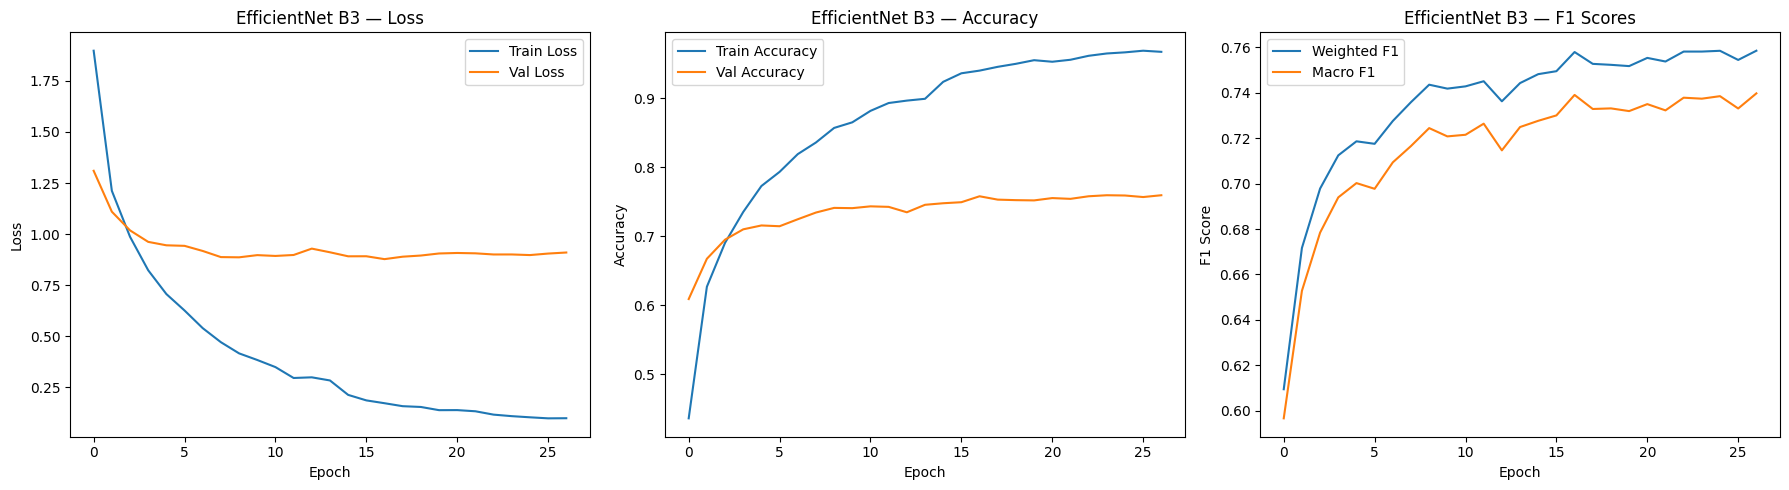

In [77]:
plot_training_history(history, "EfficientNet B3");

In [78]:
y_true, y_pred, f1_weighted, f1_macro = evaluate_model(model_effnet, val_ds, class_names)


Validation Results:
  Weighted F1: 0.7578
  Macro F1:    0.7390

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.80      0.78      0.79       116
      Boris_Kustodiev       0.55      0.55      0.55        89
     Camille_Pissarro       0.75      0.67      0.71       124
        Childe_Hassam       0.71      0.64      0.67        77
         Claude_Monet       0.71      0.81      0.76       187
          Edgar_Degas       0.69      0.78      0.73        86
        Eugene_Boudin       0.86      0.82      0.84        78
         Gustave_Dore       0.92      0.91      0.91       106
           Ilya_Repin       0.53      0.66      0.58        76
      Ivan_Aivazovsky       0.90      0.96      0.93        81
        Ivan_Shishkin       0.75      0.81      0.78        73
  John_Singer_Sargent       0.66      0.65      0.66       110
         Marc_Chagall       0.78      0.74      0.76       107
      Martiros_Saryan       0.61 

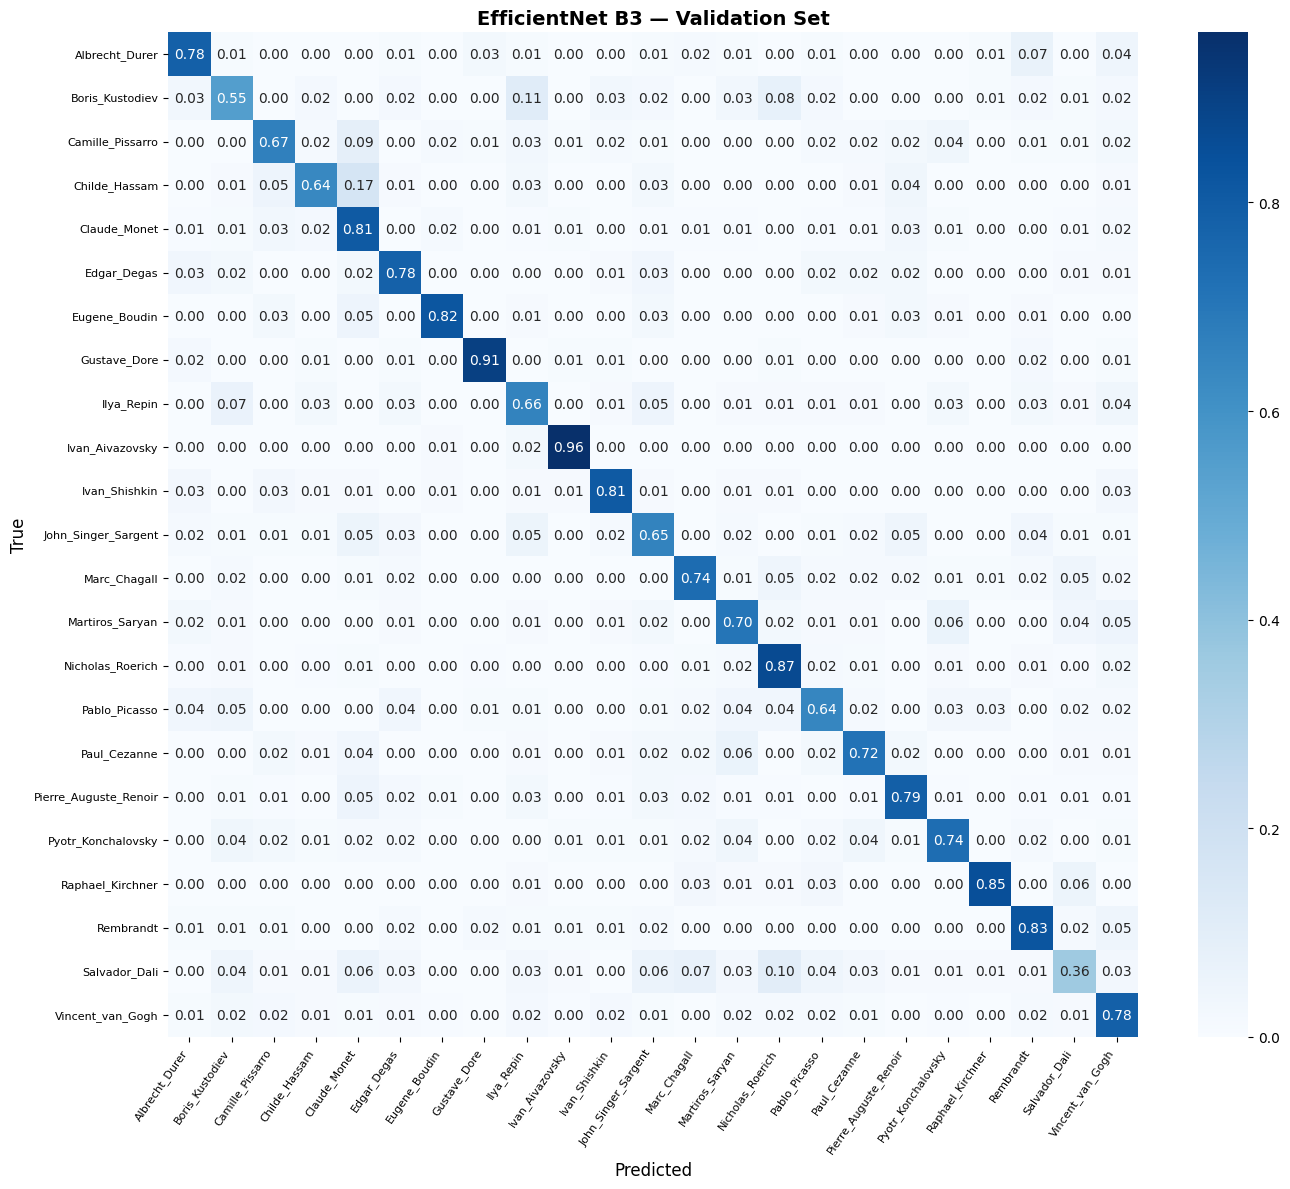

In [79]:
plot_confusion_matrix(y_true, y_pred, class_names, "EfficientNet B3 — Validation Set");

In [80]:
wandb.log({"val_f1_weighted": f1_weighted, "val_f1_macro": f1_macro})
wandb.finish()

epoch/accuracy,▁▄▄▅▅▆▆▆▇▇▇▇▇▇▇████████████
epoch/epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
epoch/learning_rate,█████████████▄▄▄▄▄▄▄▄▂▂▂▂▂▁
epoch/loss,█▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▄▅▆▆▆▆▇▇▇▇▇▇▇▇████████████
epoch/val_f1_macro,▁▄▅▆▆▆▇▇▇▇▇▇▇▇▇████████████
epoch/val_f1_weighted,▁▄▅▆▆▆▇▇▇▇▇▇▇▇█████████████
epoch/val_loss,█▅▃▂▂▂▂▁▁▁▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▂
val_f1_macro,▁
val_f1_weighted,▁
epoch/accuracy,0.96751


#### 2.3.2 With augmentation

In [81]:
augmentation_layer = keras.Sequential([
   layers.RandomZoom(0.15),
   layers.RandomFlip("horizontal"),
   layers.RandomContrast(0.1),
   layers.RandomSharpness(0.1)
], name="augmentation")

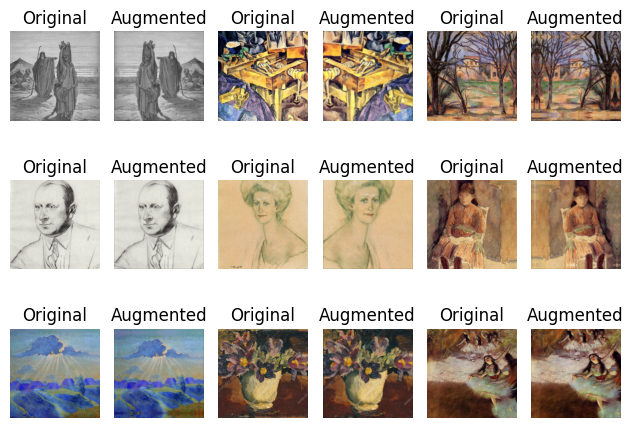

In [82]:
#Visualize original vs augmented
for images, labels in train_ds.take(1):
   for i in range(9):
       # Original — divide by 255 just for display
       ax_left = plt.subplot(3, 6, i*2 + 1)
       plt.imshow(images[i].numpy().astype("uint8"))  # treat as uint8 for display
       plt.title("Original")
       plt.axis("off")
       
       # Augmented
       paint_batch = tf.expand_dims(images[i], axis=0)
       aug_batch = augmentation_layer(paint_batch, training=True)
       aug_image = tf.clip_by_value(aug_batch[0], 0.0, 255.0)  # clip to [0,255] not [0,1]

       ax_right = plt.subplot(3, 6, i*2 + 2)
       plt.imshow(aug_image.numpy().astype("uint8"))  # treat as uint8 for display
       plt.title("Augmented")
       plt.axis("off")

plt.tight_layout()
plt.show()

In [83]:
augmented_train_ds = train_ds.map(
   lambda x, y: (augmentation_layer(x, training=True), y), num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)

In [84]:
wandb.init(
    project="wikiart-pre_trained",
    name="EfficientNetB3_aug",
    id=wandb.util.generate_id(),
    config={
        "architecture": "EfficientNetB3",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "filters": [32, 64, 128],
        "dense_units": 256,
        "dropout": 0.3,
        "augmentation": "true",
        "optimizer": "adam",
        "learning_rate": 0.001,
    }
)

In [85]:
# EfficientNetB3

# 1. Load the pre-trained EfficientNetB3 base
effnet_base = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the base model (feature extraction)
effnet_base.trainable = False

# 2. Build the Model Architecture
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Pass inputs through the base model
# training=False ensures BatchNorm layers stay in inference mode
x = effnet_base(inputs, training=False)

# 3. Custom Classification Head
# Using GlobalAveragePooling2D instead of Flatten (Crucial for EfficientNet!)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

# Final layer for the painters
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# 4. Construct and summarize
model_effnet_aug = Model(inputs, outputs, name="EfficientNetB3_WikiArt")
model_effnet_aug.summary()

# 5. Compile
model_effnet_aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "EfficientNetB3_WikiArt"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 23)             │        11,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,582,278 (44.18 MB)

 Trainable params: 798,743 (3.05 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [86]:
# Train the model
# max epochs = 100, but EarlyStopping will stop it sooner if val_loss stops improving

history = model_effnet_aug.fit(
    augmented_train_ds,
    validation_data=val_ds,
    epochs=100,
    verbose=2,
    class_weight=class_weights,
    callbacks=[
        # Stop training if val_loss doesn't improve for 10 epochs
        # restore_best_weights=True means we keep the best model, not the last one
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        # Halve the learning rate if val_loss doesn't improve for 5 epochs
        # This lets the model make finer adjustments as it gets closer to a good solution
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        F1Callback(val_ds),
        # Log metrics to W&B automatically every epoch
        WandbMetricsLogger(),
    ],
)

Epoch 1/100
 — val_f1_weighted: 0.5630 — val_f1_macro: 0.5501
126/126 - 195s - 2s/step - accuracy: 0.4215 - loss: 1.9389 - val_accuracy: 0.5652 - val_loss: 1.4235 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.5630 - val_f1_macro: 0.5501
Epoch 2/100
 — val_f1_weighted: 0.6147 — val_f1_macro: 0.5971
126/126 - 103s - 818ms/step - accuracy: 0.5860 - loss: 1.3235 - val_accuracy: 0.6105 - val_loss: 1.2659 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.6147 - val_f1_macro: 0.5971
Epoch 3/100
 — val_f1_weighted: 0.6400 — val_f1_macro: 0.6176
126/126 - 103s - 820ms/step - accuracy: 0.6521 - loss: 1.1025 - val_accuracy: 0.6330 - val_loss: 1.2080 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.6400 - val_f1_macro: 0.6176
Epoch 4/100
 — val_f1_weighted: 0.6532 — val_f1_macro: 0.6316
126/126 - 105s - 833ms/step - accuracy: 0.6950 - loss: 0.9606 - val_accuracy: 0.6457 - val_loss: 1.1563 - learning_rate: 1.0000e-03 - val_f1_weighted: 0.6532 - val_f1_macro: 0.6316
Epoch 5/100
 — val_f1_weighted:

In [87]:
train_results = evaluate_model(model_effnet_aug, augmented_train_ds, class_names, "Train" )
val_results = evaluate_model(model_effnet_aug, val_ds, class_names, "Validation")


Train Results:
  Weighted F1: 0.9879
  Macro F1:    0.9897

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.99      1.00      0.99       348
      Boris_Kustodiev       0.99      1.00      1.00       266
     Camille_Pissarro       0.98      0.98      0.98       373
        Childe_Hassam       0.96      1.00      0.98       231
         Claude_Monet       0.97      0.97      0.97       560
          Edgar_Degas       0.99      1.00      0.99       257
        Eugene_Boudin       1.00      1.00      1.00       233
         Gustave_Dore       1.00      1.00      1.00       317
           Ilya_Repin       0.98      1.00      0.99       227
      Ivan_Aivazovsky       1.00      1.00      1.00       242
        Ivan_Shishkin       0.96      1.00      0.98       218
  John_Singer_Sargent       0.99      0.99      0.99       329
         Marc_Chagall       1.00      1.00      1.00       322
      Martiros_Saryan       0.98      

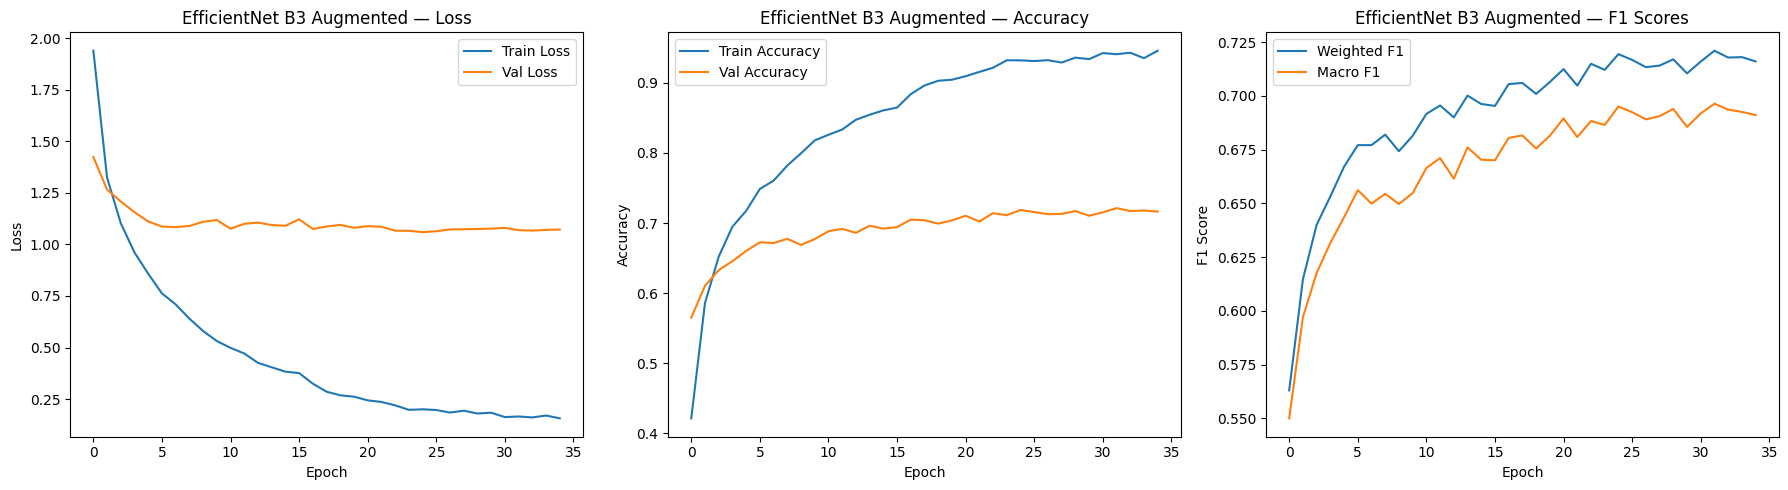

In [88]:
plot_training_history(history, "EfficientNet B3 Augmented");

In [89]:
y_true, y_pred, f1_weighted, f1_macro = evaluate_model(model_effnet_aug, val_ds, class_names)


Validation Results:
  Weighted F1: 0.7194
  Macro F1:    0.6950

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.81      0.77      0.79       116
      Boris_Kustodiev       0.60      0.46      0.52        89
     Camille_Pissarro       0.67      0.72      0.69       124
        Childe_Hassam       0.80      0.58      0.68        77
         Claude_Monet       0.71      0.78      0.74       187
          Edgar_Degas       0.60      0.66      0.63        86
        Eugene_Boudin       0.69      0.87      0.77        78
         Gustave_Dore       0.82      0.92      0.86       106
           Ilya_Repin       0.45      0.63      0.52        76
      Ivan_Aivazovsky       0.93      0.85      0.89        81
        Ivan_Shishkin       0.65      0.86      0.74        73
  John_Singer_Sargent       0.61      0.66      0.63       110
         Marc_Chagall       0.77      0.68      0.72       107
      Martiros_Saryan       0.45 

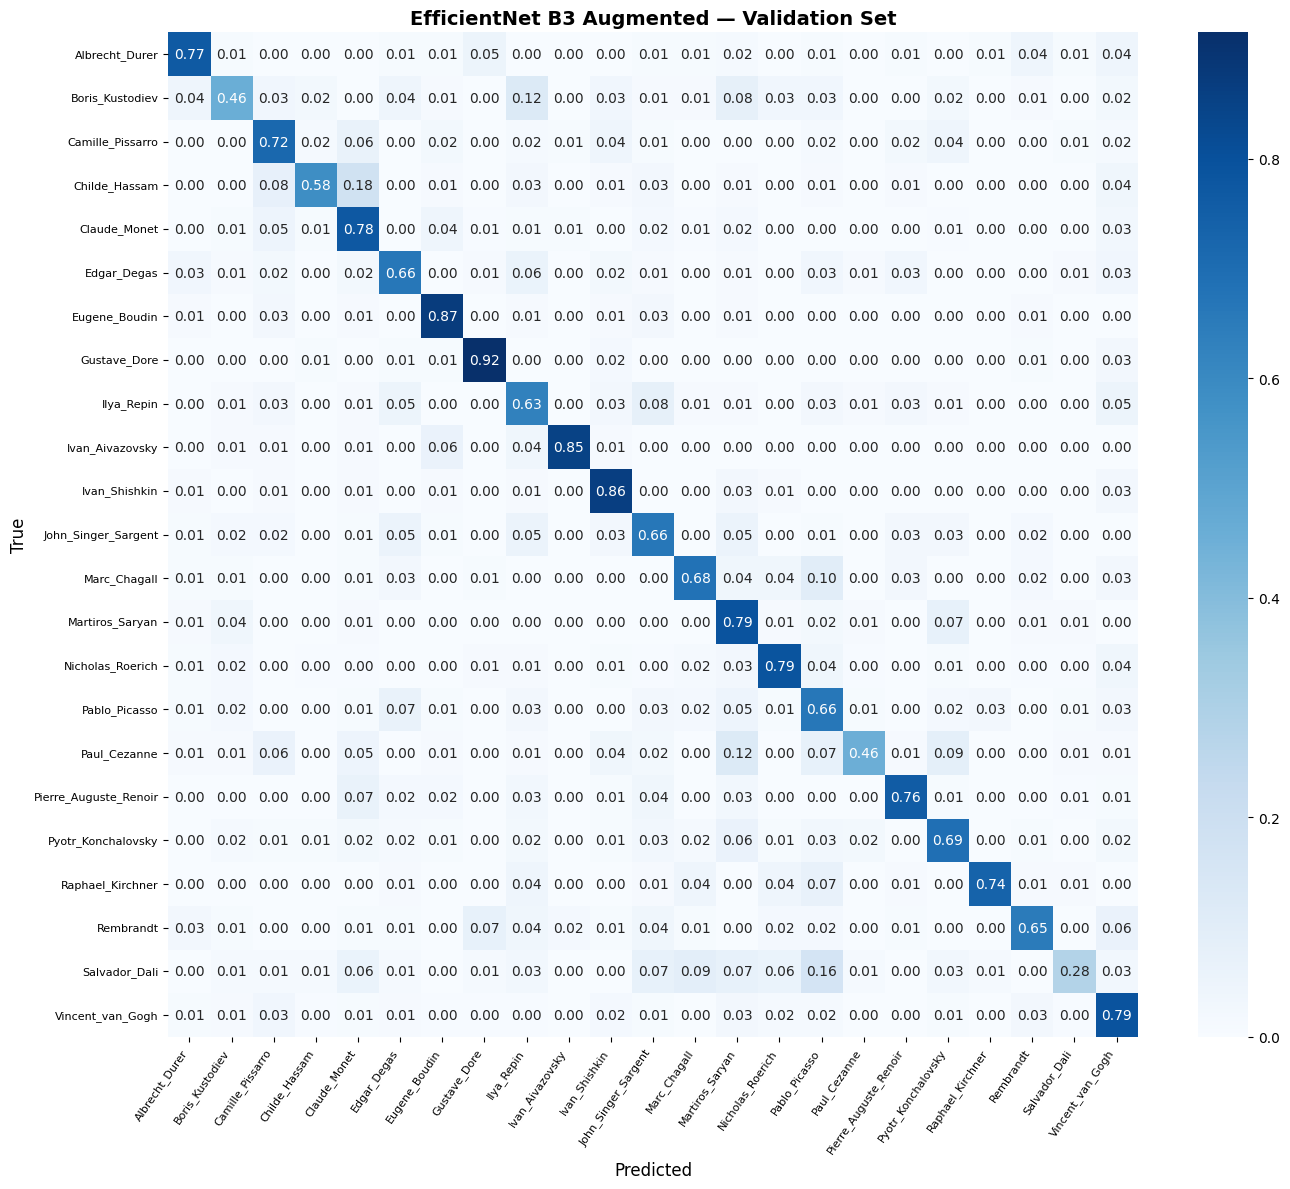

In [90]:
plot_confusion_matrix(y_true, y_pred, class_names, "EfficientNet B3 Augmented — Validation Set");

In [91]:
wandb.log({"val_f1_weighted": f1_weighted, "val_f1_macro": f1_macro})
wandb.finish()

epoch/accuracy,▁▃▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇███████████████
epoch/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,███████████████▄▄▄▄▄▄▂▂▂▂▂▂▂▂▁▁▁▁▁▁
epoch/loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▄▅▅▆▆▆▆▆▇▇▆▇▇▇▇▇▇▇█▇█████████████
epoch/val_f1_macro,▁▃▄▅▅▆▆▆▆▆▇▇▆▇▇▇▇▇▇▇█▇███████▇█████
epoch/val_f1_weighted,▁▃▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█▇█████████████
epoch/val_loss,█▅▄▃▂▂▁▂▂▂▁▂▂▂▂▂▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_f1_macro,▁
val_f1_weighted,▁
epoch/accuracy,0.94589


## 3. Apply best model to test

In [94]:
test_results = evaluate_model(model_effnet, test_ds, class_names, "Test" )


Test Results:
  Weighted F1: 0.7504
  Macro F1:    0.7296

Per-class report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.84      0.82      0.83       116
      Boris_Kustodiev       0.57      0.48      0.52        89
     Camille_Pissarro       0.71      0.64      0.67       124
        Childe_Hassam       0.66      0.60      0.63        77
         Claude_Monet       0.71      0.81      0.76       187
          Edgar_Degas       0.73      0.69      0.71        85
        Eugene_Boudin       0.82      0.83      0.83        78
         Gustave_Dore       0.90      0.91      0.91       105
           Ilya_Repin       0.46      0.56      0.51        75
      Ivan_Aivazovsky       0.87      0.91      0.89        81
        Ivan_Shishkin       0.74      0.84      0.79        73
  John_Singer_Sargent       0.61      0.67      0.64       110
         Marc_Chagall       0.74      0.71      0.72       107
      Martiros_Saryan       0.69      0